# NANOGrav 20-Year (NG20) Astrophysical Interpretation: All Parameter Spaces

This notebook demonstrates the set of new **NG20 Parameter Spaces** designed for the flagship NANOGrav 20-year astrophysics interpretation analysis.

### Framework Summary

# Note -- update this description when the code is all working

1. **Binary Evolution / Hardening:** Blecha Inside-Out (BIO) Hardening (`FixedOuterTime_InnerPL_SAM`, Model 1: boundary rate $da/dt|_{r_\mathrm{char}}$ with guaranteed physical subluminal speeds).
2. **Galaxy Stellar Mass Function (GSMF):** Double-Schechter parameterization with the full 11-dimensional covariance matrix from **Leja et al. (2020)** (`PD_MVNormal`).
3. **Galaxy Merger Rate (GMR):** Cosmological simulation-derived merger rate from **Illustris / Rodriguez-Gomez et al. (2015)** (`GMR_Illustris`).
4. **$M_\mathrm{BH}$–Host Galaxy Scaling Relation:** **Kormendy & Ho (2013)** $M_\mathrm{BH}$–$M_\mathrm{bulge}$ relation with redshift-evolving normalization $M_\mathrm{amp}(z) = M_\mathrm{amp,0}(1+z)^{\gamma_z}$ (**Matt et al. 2026a**).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import holodeck as holo
from holodeck import librarian
from holodeck.librarian.param_spaces import PS_NG20_Fiducial, PS_NG20_Fiducial_Hard, PS_NG20_Fiducial_Extended
from holodeck.librarian.param_spaces_classic import PS_Classic_Phenom_Astro_Extended
from holodeck.constants import MSOL, GYR, PC, YR

from corner import corner

print("Holodeck version:", holo.__version__)

Holodeck version: 1.6


## 1. Parameter Space List

1. **NG20 Fiducial** (`PS_NG20_Fiducial`)
    - Blecha (2026) Inside-Out (BIO) Hardening (`FixedOuterTime_InnerPL_SAM`, Model 0)
    - Double-Schechter GSMF with Leja+2020 11-D covariance matrix (`PD_MVNormal`)
    - Illustris Galaxy Merger Rate (`GMR_Illustris`)
    - Kormendy & Ho (2013) M-Mbulge with Matt et al. (2026a) redshift-evolving amplitude
2. **NG20 'Hard' Fiducial** (`PS_NG20_Fiducial_Hard`)
    - Blecha (2026) Inside-Out (BIO) Hardening (`FixedOuterTime_InnerPL_SAM`, Model 0)
    - Double-Schechter GSMF with Leja+2020 11-D covariance matrix (`PD_MVNormal`)
    - Illustris Galaxy Merger Rate (`GMR_Illustris`)
    - Kormendy & Ho (2013) M-Mbulge with **no** redshift evolution
3. **Potential NG20 Extended** (`PS_NG20_Fiducial_Extended`; Note that the exact formulation here is still in flux).
    - Blecha (2026) Inside-Out (BIO) Hardening (`FixedOuterTime_InnerPL_SAM`, Model 0)
    - Double-Schechter GSMF with Leja+2020 11-D covariance matrix (`PD_MVNormal`)
    - Illustris Galaxy Merger Rate (`GMR_Illustris`)
    - Kormendy & Ho (2013) M-Mbulge with Matt et al. (2026a) redshift-evolving amplitude, (TBD: slope, and scatter)
    - TBD: Variable bulge fraction and scatter

## 2. NG20 Fiducial

In [2]:
# Instantiate the NG20 Fiducial parameter space with N=1000 Latin Hypercube samples
NSAMPLES = 1000
ps_ng20 = PS_NG20_Fiducial(holo.log, nsamples=NSAMPLES, seed=42, sam_shape=[100,100,100])

print(f"Total free parameter dimensions: {len(ps_ng20.param_names)}")
print(f"Sample array shape: {ps_ng20.param_samples.shape}\n")

print("Parameter Names and Defaults:")
for name in ps_ng20.param_names:
    def_val = ps_ng20.DEFAULTS.get(name, 'N/A')
    print(f"  - {name:<26}: default = {def_val}")

18:23:02 WARNING : found rgw_crit<=risco. Setting to risco for these binaries with no GW phase. [utils.py:get_nuin_min]
18:23:03 WARNING : found rgw_crit<=risco. Setting to risco for these binaries with no GW phase. [utils.py:get_nuin_min]
Total free parameter dimensions: 27
Sample array shape: (1000, 27)

Parameter Names and Defaults:
  - hard_outer_time           : default = 1.0
  - hard_r_gw_crit_9_log10    : default = 2.5
  - hard_nu_inner             : default = 0.0
  - gsmf_log10_phi_one_z0     : default = -2.386
  - gsmf_log10_phi_one_z1     : default = -0.259
  - gsmf_log10_phi_one_z2     : default = -0.11
  - gsmf_log10_phi_two_z0     : default = -2.821
  - gsmf_log10_phi_two_z1     : default = -0.368
  - gsmf_log10_phi_two_z2     : default = 0.046
  - gsmf_log10_mstar_z0       : default = 10.765
  - gsmf_log10_mstar_z1       : default = 0.13
  - gsmf_log10_mstar_z2       : default = -0.034
  - gsmf_alpha_one            : default = -0.278
  - gsmf_alpha_two            : defaul

In [3]:
samples_ng20 = {name: ps_ng20.param_samples[:, i] for i, name in enumerate(ps_ng20.param_names)}
len(samples_ng20)

27

In [4]:
samples_ng20['hard_outer_time'].shape

(1000,)

In [5]:
## preprocess
samples_ng20_arr = np.array([samples_ng20[key] for key in samples_ng20.keys()])

In [6]:
samples_ng20.keys()

dict_keys(['hard_outer_time', 'hard_r_gw_crit_9_log10', 'hard_nu_inner', 'gsmf_log10_phi_one_z0', 'gsmf_log10_phi_one_z1', 'gsmf_log10_phi_one_z2', 'gsmf_log10_phi_two_z0', 'gsmf_log10_phi_two_z1', 'gsmf_log10_phi_two_z2', 'gsmf_log10_mstar_z0', 'gsmf_log10_mstar_z1', 'gsmf_log10_mstar_z2', 'gsmf_alpha_one', 'gsmf_alpha_two', 'gmr_norm0_log10', 'gmr_normz', 'gmr_malpha0', 'gmr_malphaz', 'gmr_mdelta0', 'gmr_mdeltaz', 'gmr_qgamma0', 'gmr_qgammaz', 'gmr_qgammam', 'mmb_mamp_log10', 'mmb_plaw', 'mmb_scatter_dex', 'mmb_zplaw_amp'])

In [7]:
## too many parameters to view at once, so let's break them out by category
hardening_params = ['hard_outer_time', 'hard_r_gw_crit_9_log10', 'hard_nu_inner']
hardening_idx = np.arange(len(samples_ng20))[[param in hardening_params for param in samples_ng20.keys()]]
gsmf_params = ['gsmf_log10_phi_one_z0', 'gsmf_log10_phi_one_z1', 'gsmf_log10_phi_one_z2',
               'gsmf_log10_phi_two_z0', 'gsmf_log10_phi_two_z1', 'gsmf_log10_phi_two_z2',
               'gsmf_log10_mstar_z0', 'gsmf_log10_mstar_z1', 'gsmf_log10_mstar_z2',
               'gsmf_alpha_one', 'gsmf_alpha_two']
gsmf_idx = np.arange(len(samples_ng20))[[param in gsmf_params for param in samples_ng20.keys()]]
gmr_params = ['gmr_norm0_log10', 'gmr_normz', 'gmr_malpha0', 'gmr_malphaz', 
              'gmr_mdelta0', 'gmr_mdeltaz', 'gmr_qgamma0', 'gmr_qgammaz', 'gmr_qgammam']
gmr_idx = np.arange(len(samples_ng20))[[param in gmr_params for param in samples_ng20.keys()]]
mmb_params = ['mmb_mamp_log10', 'mmb_plaw', 'mmb_scatter_dex', 'mmb_zplaw_amp']
mmb_idx = np.arange(len(samples_ng20))[[param in mmb_params for param in samples_ng20.keys()]]

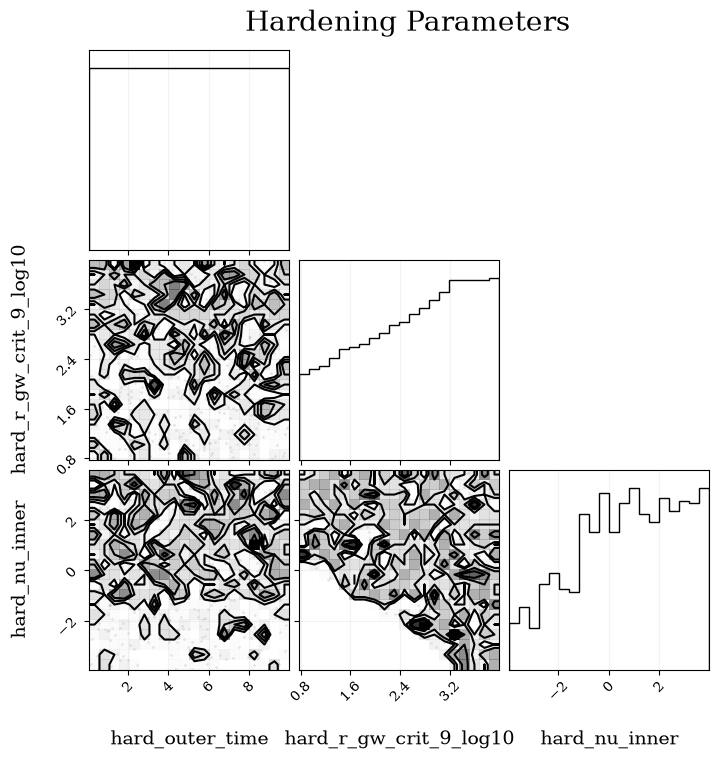

In [8]:
corner(samples_ng20_arr[hardening_idx,:].T,labels=hardening_params,label_kwargs={'fontsize':14})
plt.suptitle('Hardening Parameters',x=0.55,y=1.0,fontsize=20)
plt.show()

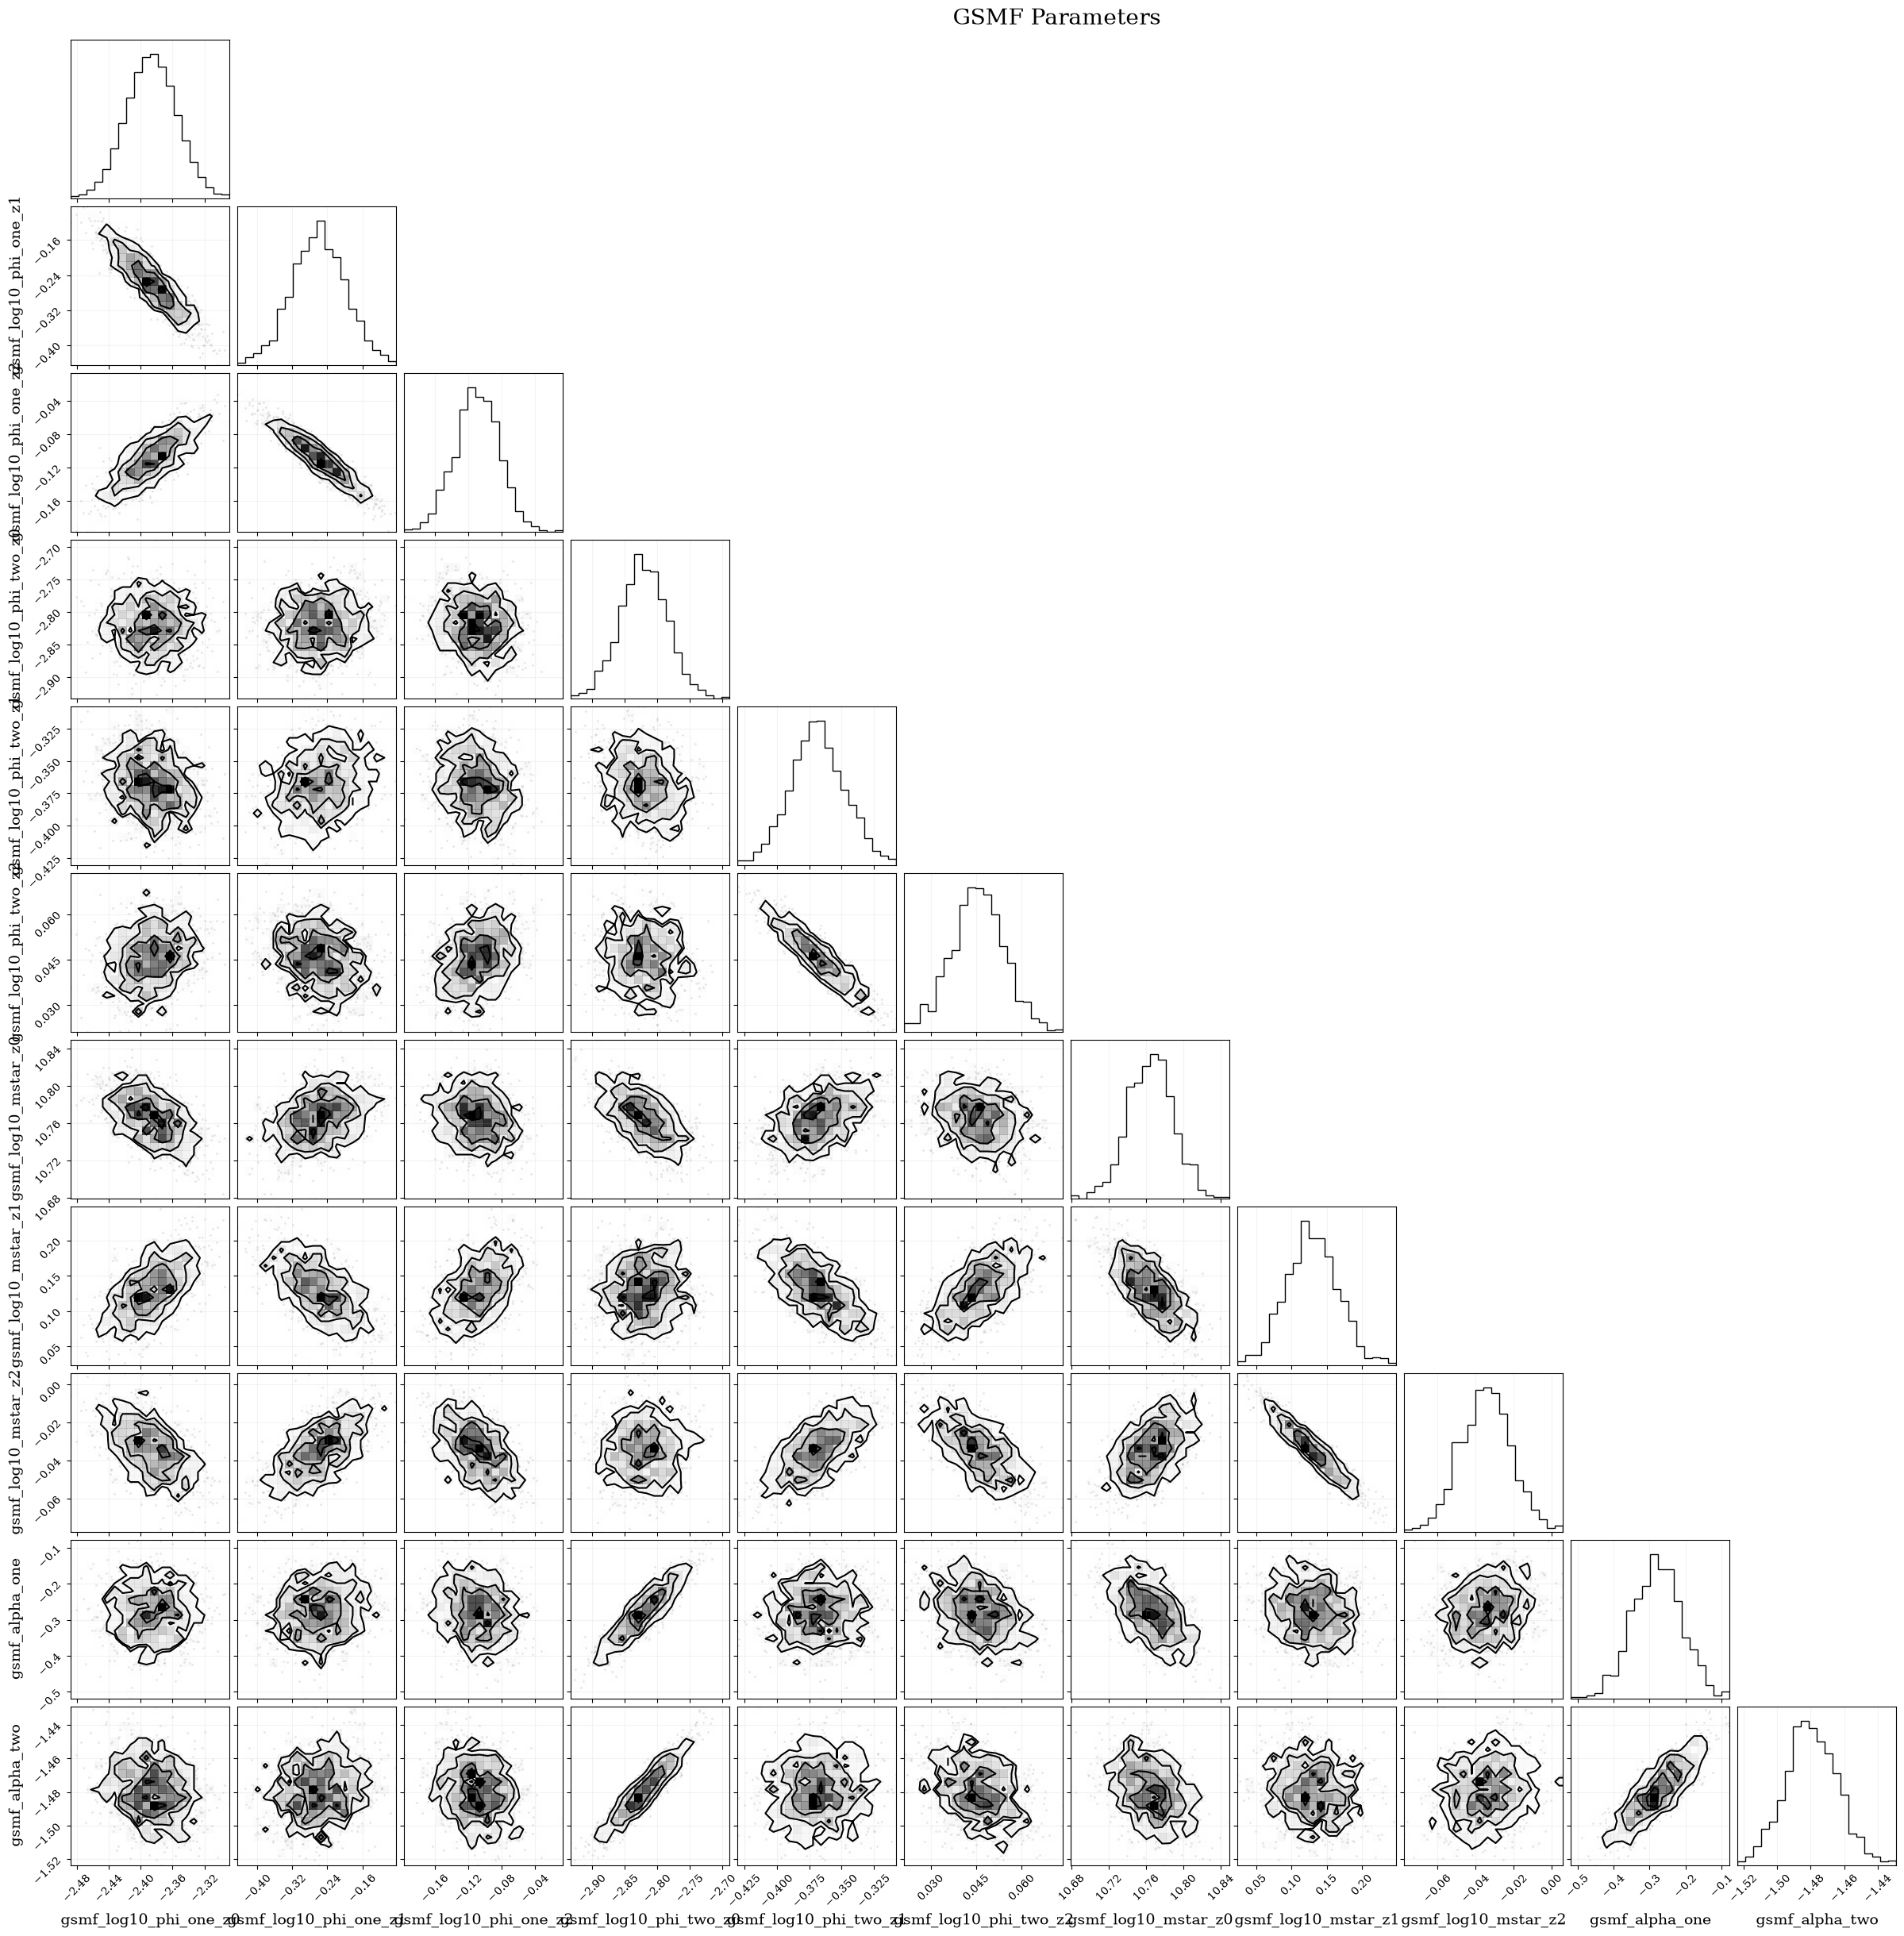

In [9]:
corner(samples_ng20_arr[gsmf_idx,:].T,labels=gsmf_params,label_kwargs={'fontsize':14})
plt.suptitle('GSMF Parameters',x=0.55,y=1.0,fontsize=20)
plt.show()

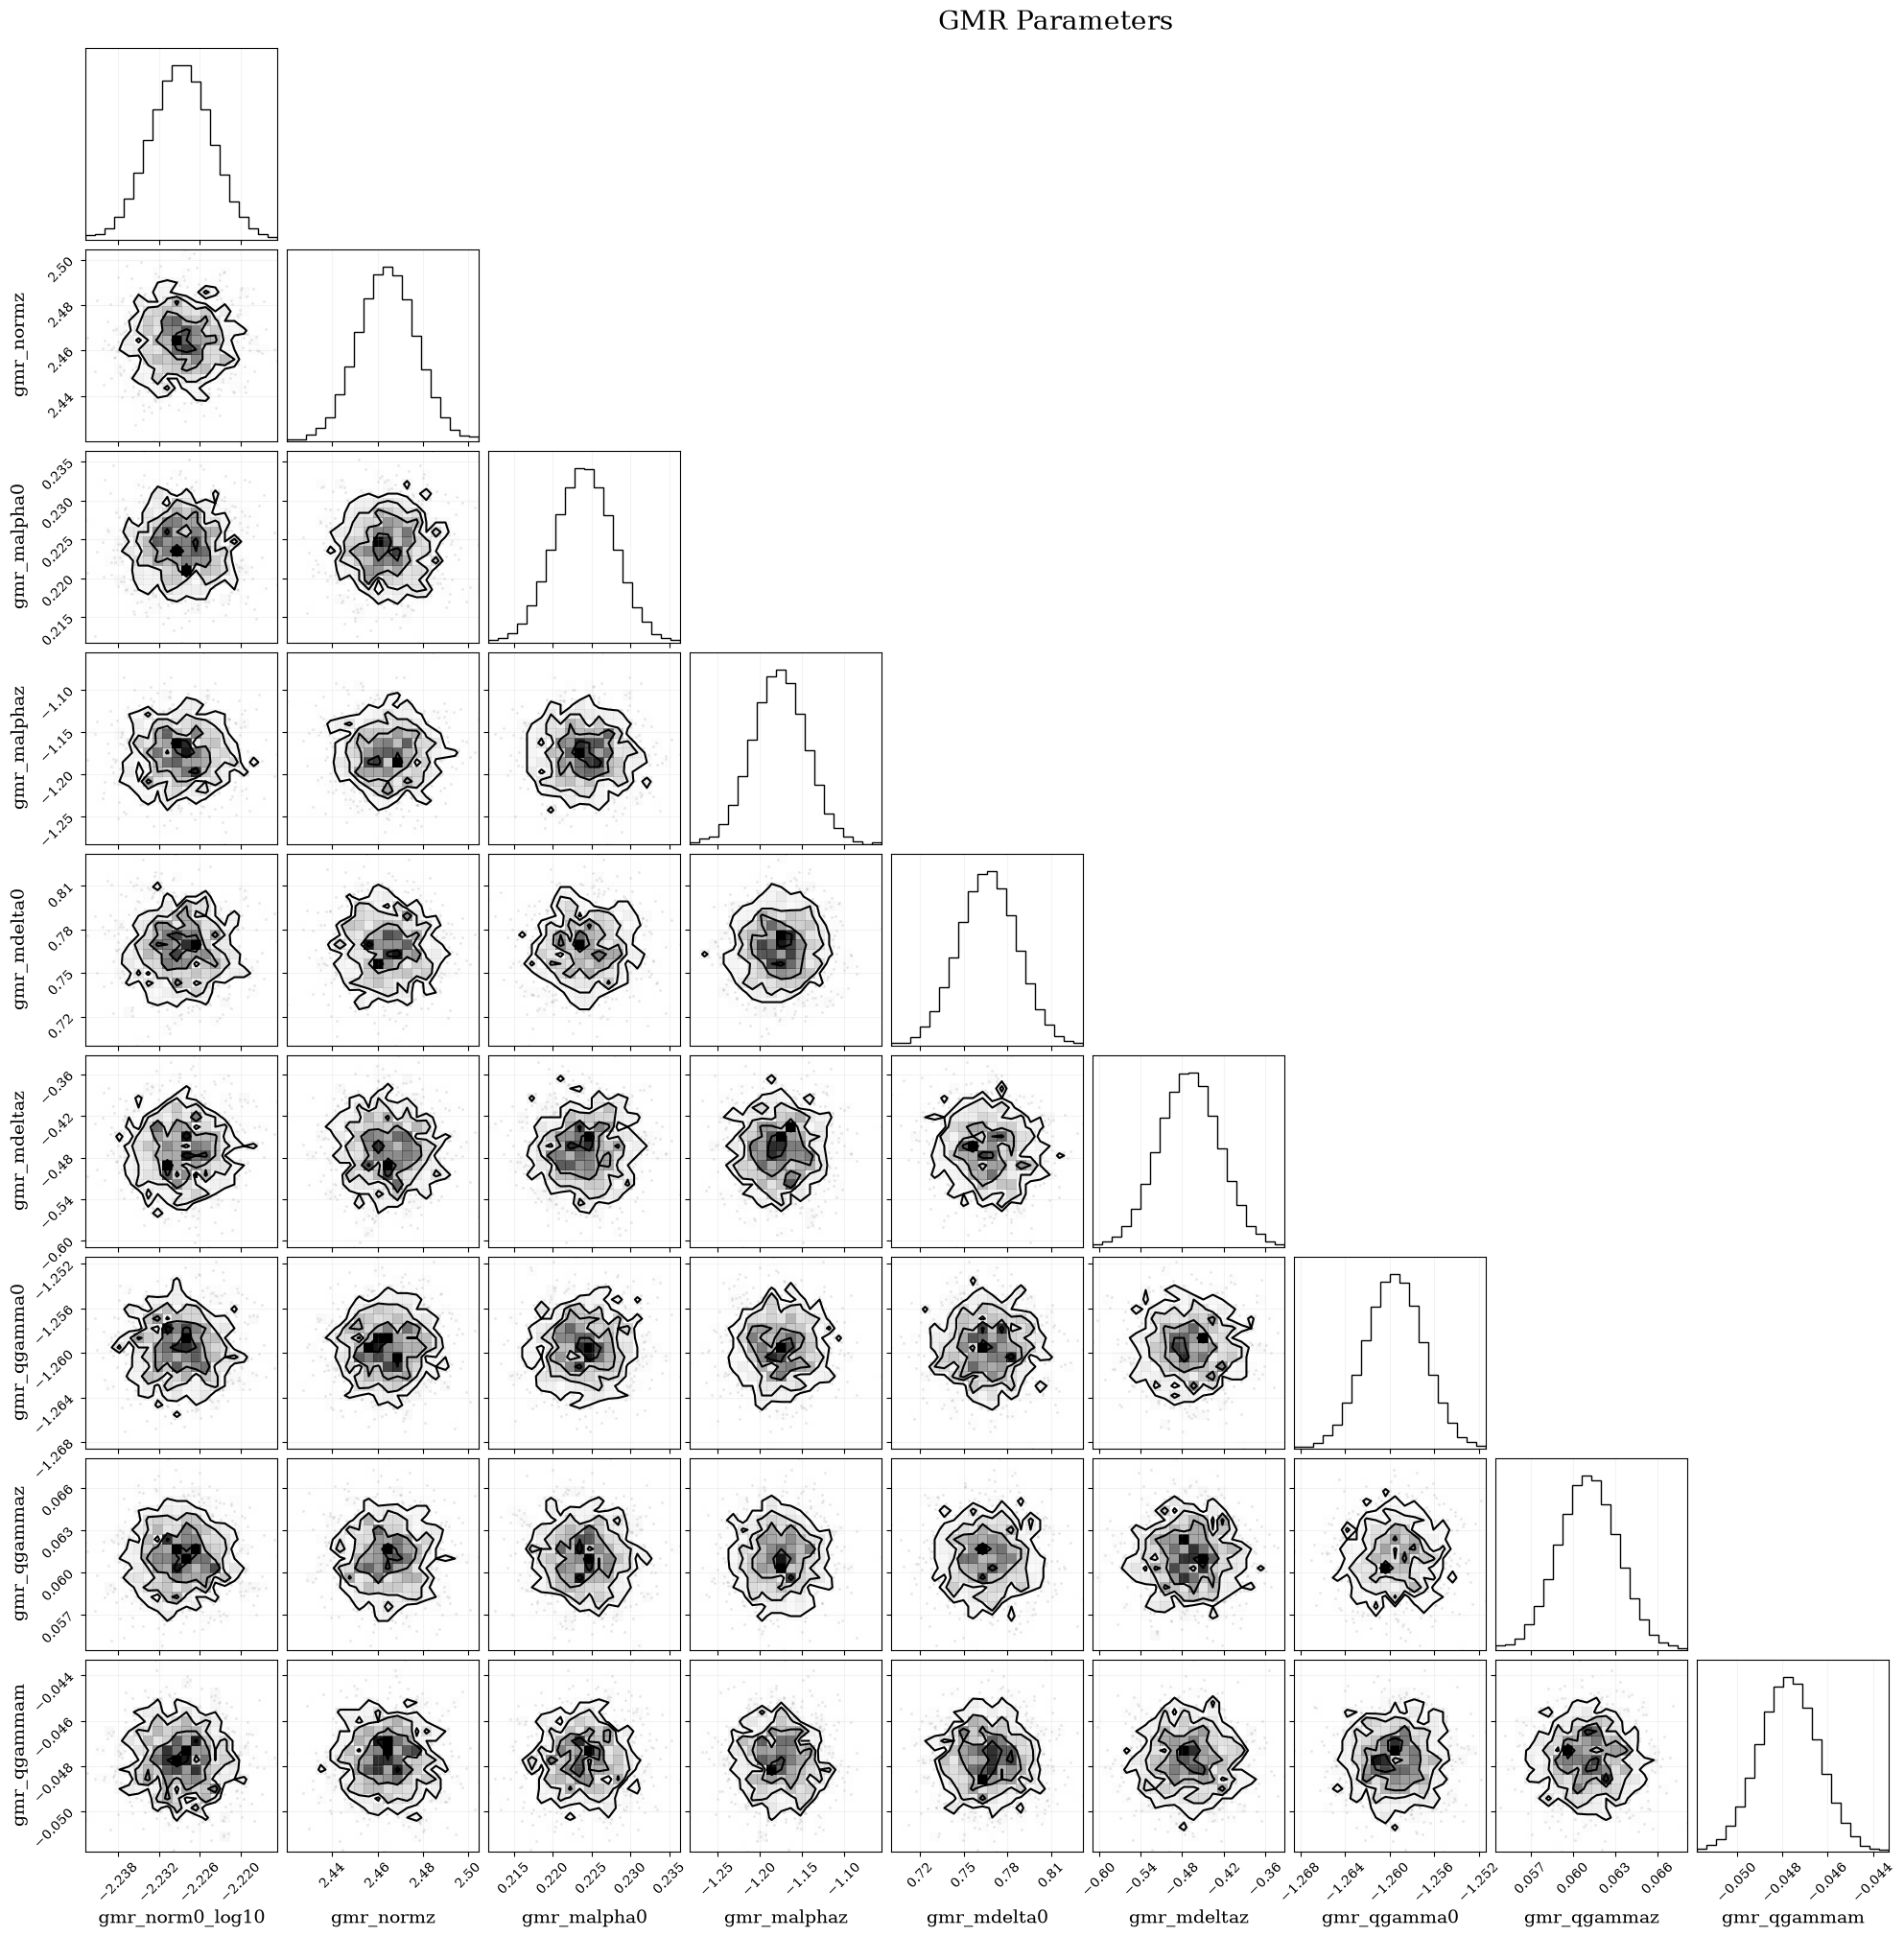

In [10]:
corner(samples_ng20_arr[gmr_idx,:].T,labels=gmr_params,label_kwargs={'fontsize':14})
plt.suptitle('GMR Parameters',x=0.55,y=1.0,fontsize=20)
plt.show()

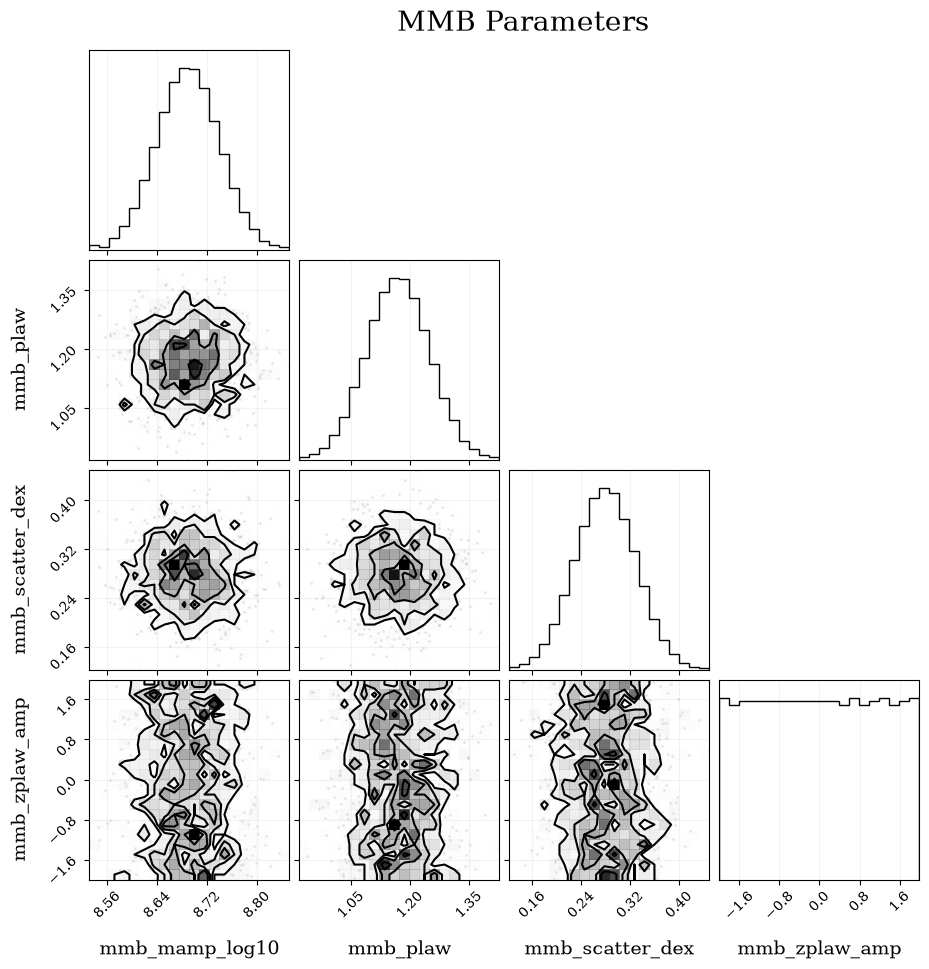

In [11]:
corner(samples_ng20_arr[mmb_idx,:].T,labels=mmb_params,label_kwargs={'fontsize':14})
plt.suptitle('MMB Parameters',x=0.55,y=1.0,fontsize=20)
plt.show()

## 2. NG20 'Hard' Fiducial

In [12]:
# Instantiate the NG20 Fiducial parameter space with N=1000 Latin Hypercube samples
NSAMPLES = 1000
ps_ng20_hard = PS_NG20_Fiducial_Hard(holo.log, nsamples=NSAMPLES, seed=42, sam_shape=[100,100,100])

print(f"Total free parameter dimensions: {len(ps_ng20_hard.param_names)}")
print(f"Sample array shape: {ps_ng20_hard.param_samples.shape}\n")

print("Parameter Names and Defaults:")
for name in ps_ng20_hard.param_names:
    def_val = ps_ng20_hard.DEFAULTS.get(name, 'N/A')
    print(f"  - {name:<26}: default = {def_val}")

18:23:06 WARNING : found rgw_crit<=risco. Setting to risco for these binaries with no GW phase. [utils.py:get_nuin_min]
18:23:07 WARNING : found rgw_crit<=risco. Setting to risco for these binaries with no GW phase. [utils.py:get_nuin_min]
Total free parameter dimensions: 26
Sample array shape: (1000, 26)

Parameter Names and Defaults:
  - hard_outer_time           : default = 1.0
  - hard_r_gw_crit_9_log10    : default = 2.5
  - hard_nu_inner             : default = 0.0
  - gsmf_log10_phi_one_z0     : default = -2.386
  - gsmf_log10_phi_one_z1     : default = -0.259
  - gsmf_log10_phi_one_z2     : default = -0.11
  - gsmf_log10_phi_two_z0     : default = -2.821
  - gsmf_log10_phi_two_z1     : default = -0.368
  - gsmf_log10_phi_two_z2     : default = 0.046
  - gsmf_log10_mstar_z0       : default = 10.765
  - gsmf_log10_mstar_z1       : default = 0.13
  - gsmf_log10_mstar_z2       : default = -0.034
  - gsmf_alpha_one            : default = -0.278
  - gsmf_alpha_two            : defaul

In [13]:
samples_ng20_hard = {name: ps_ng20_hard.param_samples[:, i] for i, name in enumerate(ps_ng20_hard.param_names)}
len(samples_ng20_hard)

26

In [14]:
samples_ng20_hard['hard_outer_time'].shape

(1000,)

In [15]:
## preprocess
samples_ng20_hard_arr = np.array([samples_ng20_hard[key] for key in samples_ng20_hard.keys()])

In [16]:
samples_ng20_hard.keys()

dict_keys(['hard_outer_time', 'hard_r_gw_crit_9_log10', 'hard_nu_inner', 'gsmf_log10_phi_one_z0', 'gsmf_log10_phi_one_z1', 'gsmf_log10_phi_one_z2', 'gsmf_log10_phi_two_z0', 'gsmf_log10_phi_two_z1', 'gsmf_log10_phi_two_z2', 'gsmf_log10_mstar_z0', 'gsmf_log10_mstar_z1', 'gsmf_log10_mstar_z2', 'gsmf_alpha_one', 'gsmf_alpha_two', 'gmr_norm0_log10', 'gmr_normz', 'gmr_malpha0', 'gmr_malphaz', 'gmr_mdelta0', 'gmr_mdeltaz', 'gmr_qgamma0', 'gmr_qgammaz', 'gmr_qgammam', 'mmb_mamp_log10', 'mmb_plaw', 'mmb_scatter_dex'])

In [17]:
## too many parameters to view at once, so let's break them out by category
hardening_params_h = ['hard_outer_time', 'hard_r_gw_crit_9_log10', 'hard_nu_inner']
hardening_idx_h = np.arange(len(samples_ng20_hard))[[param in hardening_params_h for param in samples_ng20_hard.keys()]]
gsmf_params_h = ['gsmf_log10_phi_one_z0', 'gsmf_log10_phi_one_z1', 'gsmf_log10_phi_one_z2',
               'gsmf_log10_phi_two_z0', 'gsmf_log10_phi_two_z1', 'gsmf_log10_phi_two_z2',
               'gsmf_log10_mstar_z0', 'gsmf_log10_mstar_z1', 'gsmf_log10_mstar_z2',
               'gsmf_alpha_one', 'gsmf_alpha_two']
gsmf_idx_h = np.arange(len(samples_ng20_hard))[[param in gsmf_params_h for param in samples_ng20_hard.keys()]]
gmr_params_h = ['gmr_norm0_log10', 'gmr_normz', 'gmr_malpha0', 'gmr_malphaz', 
              'gmr_mdelta0', 'gmr_mdeltaz', 'gmr_qgamma0', 'gmr_qgammaz', 'gmr_qgammam']
gmr_idx_h = np.arange(len(samples_ng20_hard))[[param in gmr_params_h for param in samples_ng20_hard.keys()]]
mmb_params_h = ['mmb_mamp_log10', 'mmb_plaw', 'mmb_scatter_dex']
mmb_idx_h = np.arange(len(samples_ng20_hard))[[param in mmb_params_h for param in samples_ng20_hard.keys()]]

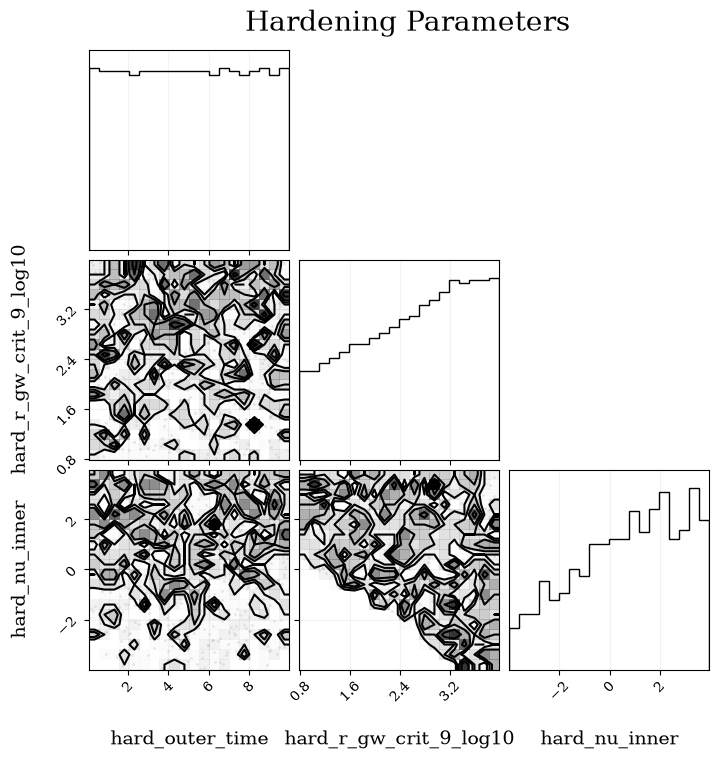

In [18]:
corner(samples_ng20_hard_arr[hardening_idx_h,:].T,labels=hardening_params_h,label_kwargs={'fontsize':14})
plt.suptitle('Hardening Parameters',x=0.55,y=1.0,fontsize=20)
plt.show()

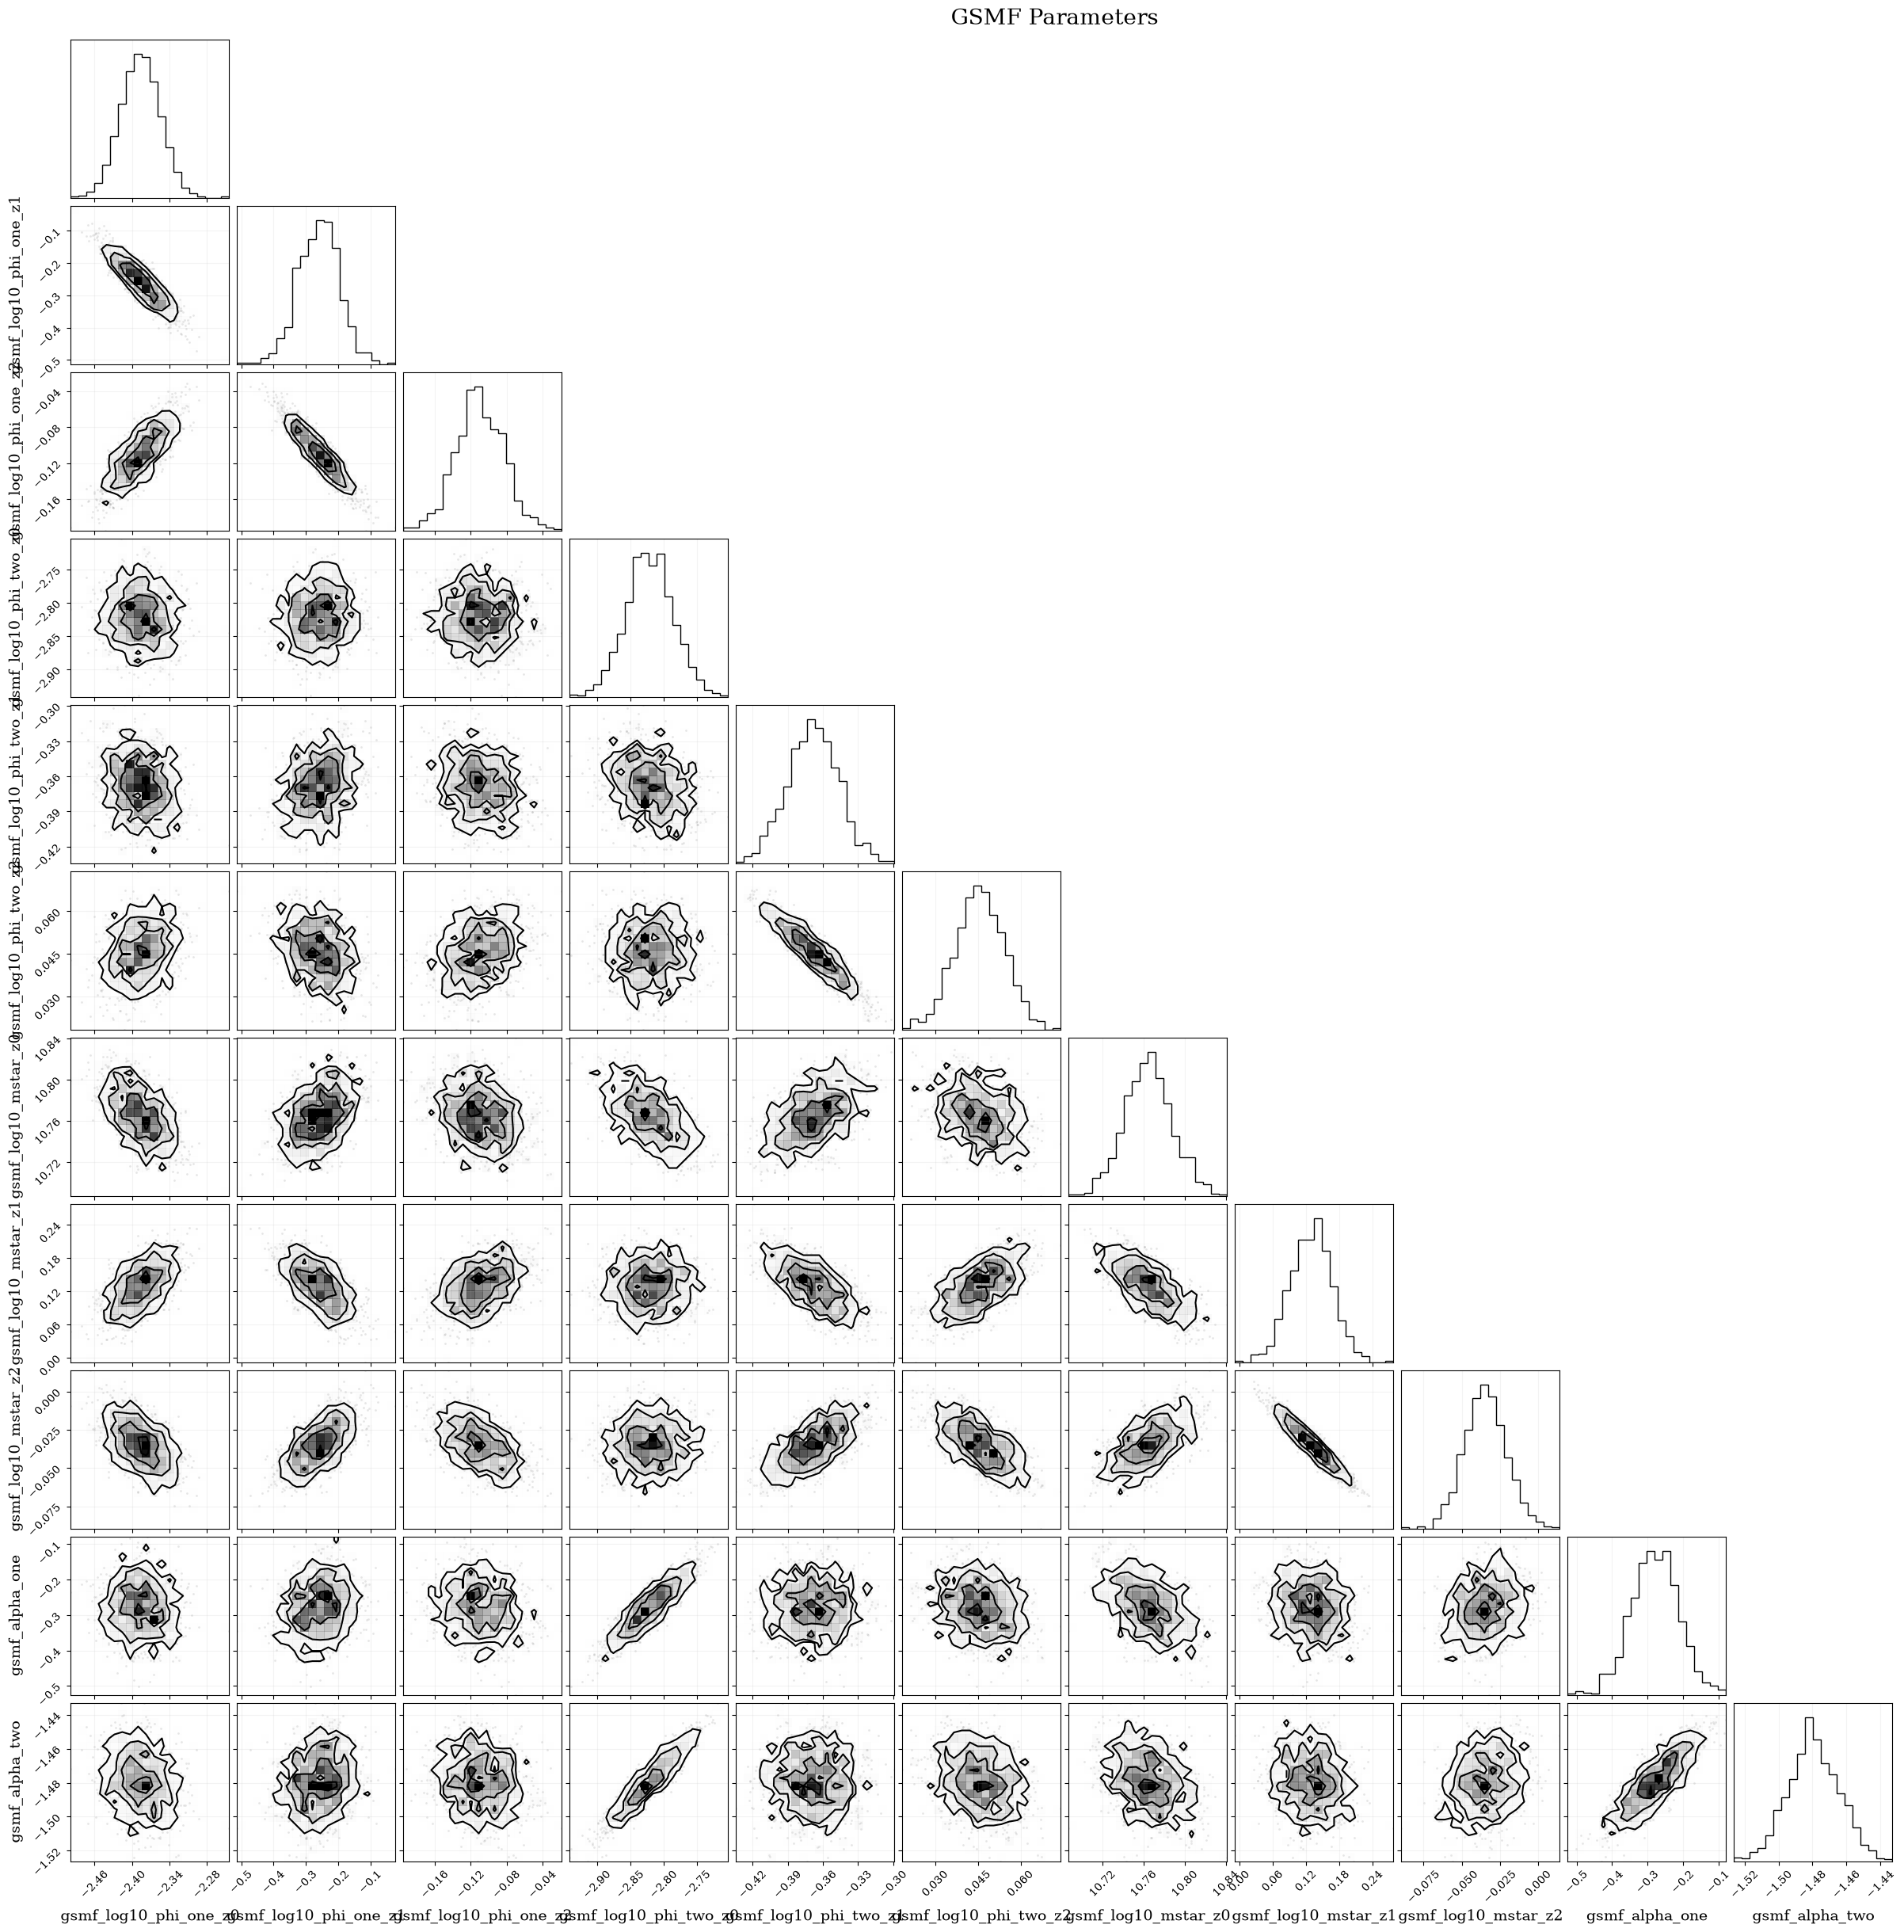

In [19]:
corner(samples_ng20_hard_arr[gsmf_idx_h,:].T,labels=gsmf_params_h,label_kwargs={'fontsize':14})
plt.suptitle('GSMF Parameters',x=0.55,y=1.0,fontsize=20)
plt.show()

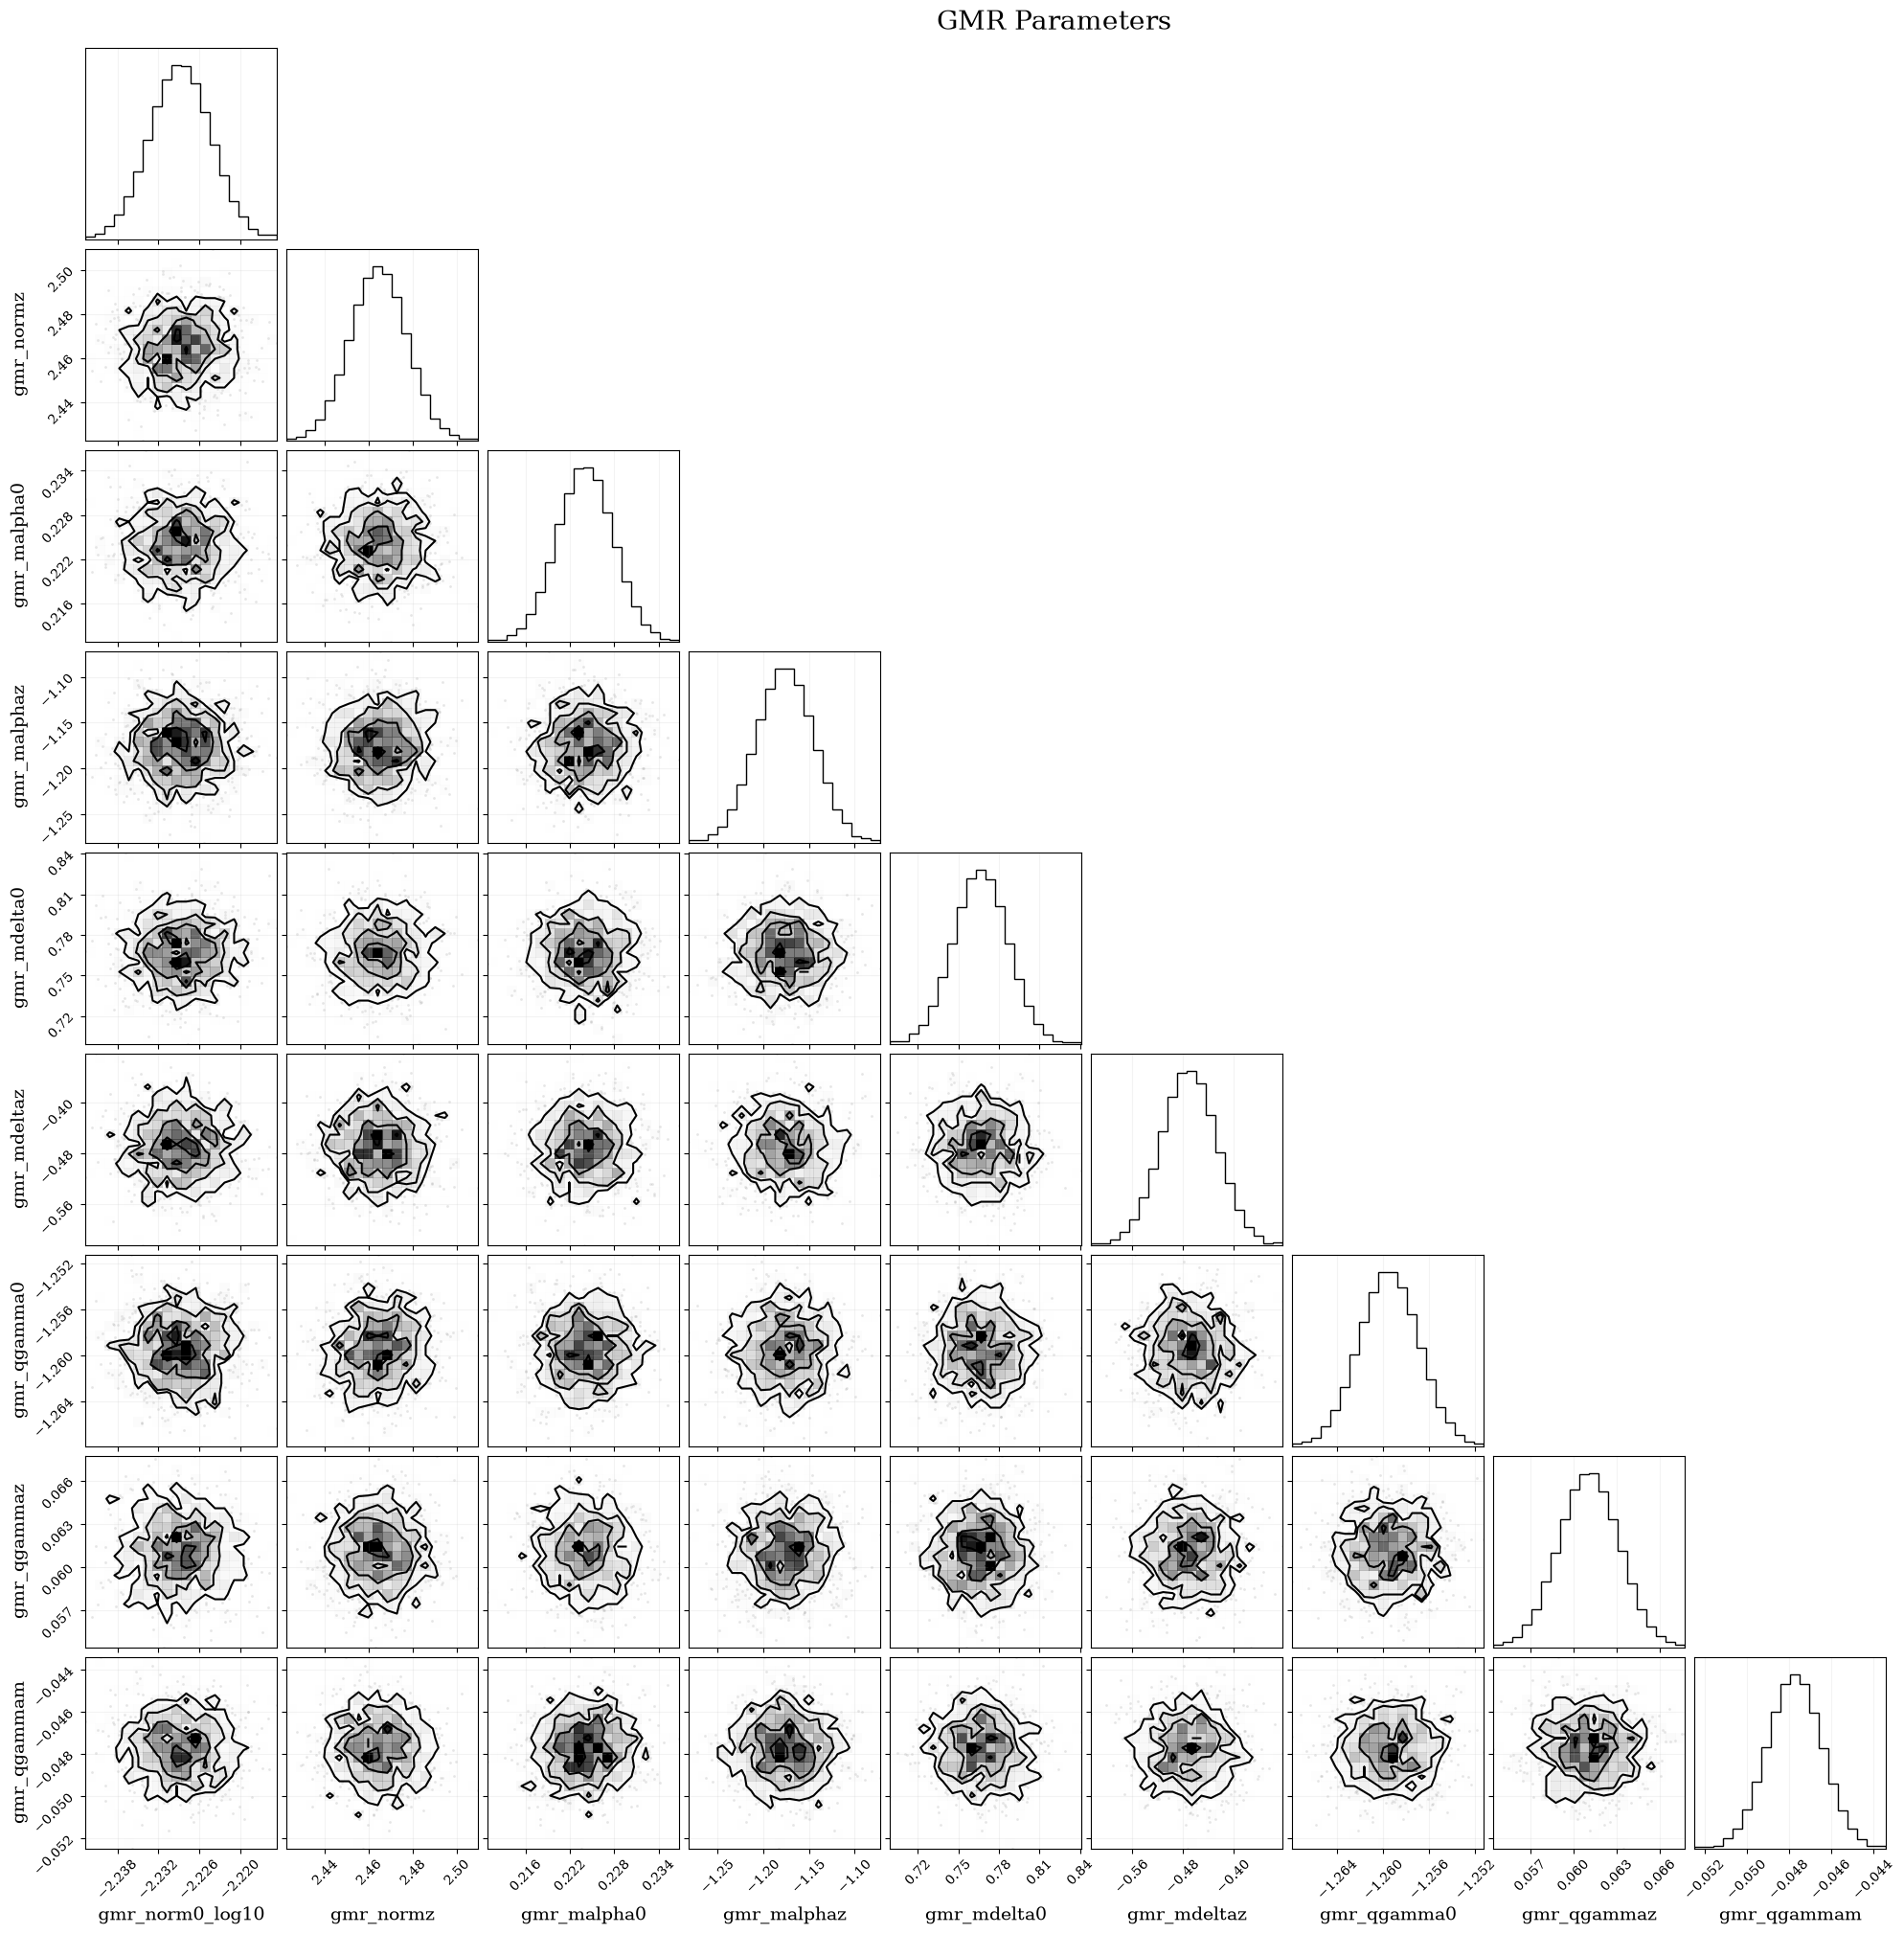

In [20]:
corner(samples_ng20_hard_arr[gmr_idx_h,:].T,labels=gmr_params_h,label_kwargs={'fontsize':14})
plt.suptitle('GMR Parameters',x=0.55,y=1.0,fontsize=20)
plt.show()

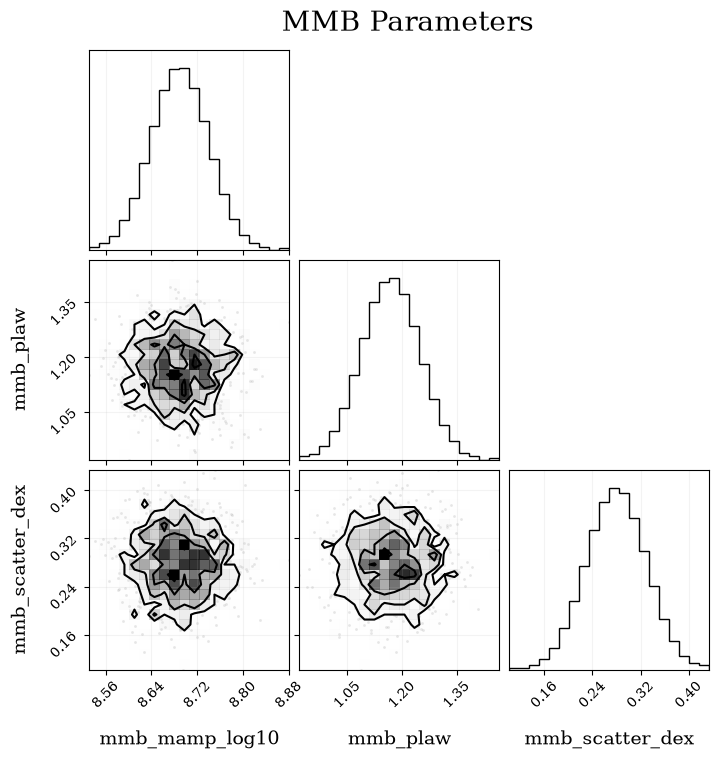

In [21]:
corner(samples_ng20_hard_arr[mmb_idx_h,:].T,labels=mmb_params_h,label_kwargs={'fontsize':14})
plt.suptitle('MMB Parameters',x=0.55,y=1.0,fontsize=20)
plt.show()

## 3. NG20 Extended

In [22]:
# Instantiate the NG20 Fiducial parameter space with N=1000 Latin Hypercube samples
NSAMPLES = 1000
ps_ng20_extended = PS_NG20_Fiducial_Extended(holo.log, nsamples=NSAMPLES, seed=42, sam_shape=[100,100,100])

print(f"Total free parameter dimensions: {len(ps_ng20_extended.param_names)}")
print(f"Sample array shape: {ps_ng20_extended.param_samples.shape}\n")

print("Parameter Names and Defaults:")
for name in ps_ng20_extended.param_names:
    def_val = ps_ng20_extended.DEFAULTS.get(name, 'N/A')
    print(f"  - {name:<26}: default = {def_val}")

18:23:10 WARNING : found rgw_crit<=risco. Setting to risco for these binaries with no GW phase. [utils.py:get_nuin_min]
18:23:11 WARNING : found rgw_crit<=risco. Setting to risco for these binaries with no GW phase. [utils.py:get_nuin_min]
Total free parameter dimensions: 32
Sample array shape: (1000, 32)

Parameter Names and Defaults:
  - hard_outer_time           : default = 1.0
  - hard_r_gw_crit_9_log10    : default = 2.5
  - hard_nu_inner             : default = 0.0
  - gsmf_log10_phi_one_z0     : default = -2.386
  - gsmf_log10_phi_one_z1     : default = -0.259
  - gsmf_log10_phi_one_z2     : default = -0.11
  - gsmf_log10_phi_two_z0     : default = -2.821
  - gsmf_log10_phi_two_z1     : default = -0.368
  - gsmf_log10_phi_two_z2     : default = 0.046
  - gsmf_log10_mstar_z0       : default = 10.765
  - gsmf_log10_mstar_z1       : default = 0.13
  - gsmf_log10_mstar_z2       : default = -0.034
  - gsmf_alpha_one            : default = -0.278
  - gsmf_alpha_two            : defaul

In [23]:
samples_ng20_extended = {name: ps_ng20_extended.param_samples[:, i] for i, name in enumerate(ps_ng20_extended.param_names)}
len(samples_ng20_extended)

32

In [24]:
samples_ng20_extended['hard_outer_time'].shape

(1000,)

In [25]:
## preprocess
samples_ng20_extended_arr = np.array([samples_ng20_extended[key] for key in samples_ng20_extended.keys()])

In [26]:
samples_ng20_extended.keys()

dict_keys(['hard_outer_time', 'hard_r_gw_crit_9_log10', 'hard_nu_inner', 'gsmf_log10_phi_one_z0', 'gsmf_log10_phi_one_z1', 'gsmf_log10_phi_one_z2', 'gsmf_log10_phi_two_z0', 'gsmf_log10_phi_two_z1', 'gsmf_log10_phi_two_z2', 'gsmf_log10_mstar_z0', 'gsmf_log10_mstar_z1', 'gsmf_log10_mstar_z2', 'gsmf_alpha_one', 'gsmf_alpha_two', 'gmr_norm0_log10', 'gmr_normz', 'gmr_malpha0', 'gmr_malphaz', 'gmr_mdelta0', 'gmr_mdeltaz', 'gmr_qgamma0', 'gmr_qgammaz', 'gmr_qgammam', 'mmb_mamp_log10', 'mmb_plaw', 'mmb_scatter_dex', 'mmb_zplaw_amp', 'mmb_zplaw_slope', 'mmb_zplaw_scatter', 'bf_frac_lo', 'bf_frac_hi', 'bf_width_dex'])

In [27]:
## too many parameters to view at once, so let's break them out by category
hardening_params_e = ['hard_outer_time', 'hard_r_gw_crit_9_log10', 'hard_nu_inner']
hardening_idx_e = np.arange(len(samples_ng20_extended))[[param in hardening_params_e for param in samples_ng20_extended.keys()]]
gsmf_params_e = ['gsmf_log10_phi_one_z0', 'gsmf_log10_phi_one_z1', 'gsmf_log10_phi_one_z2',
               'gsmf_log10_phi_two_z0', 'gsmf_log10_phi_two_z1', 'gsmf_log10_phi_two_z2',
               'gsmf_log10_mstar_z0', 'gsmf_log10_mstar_z1', 'gsmf_log10_mstar_z2',
               'gsmf_alpha_one', 'gsmf_alpha_two']
gsmf_idx_e = np.arange(len(samples_ng20_extended))[[param in gsmf_params_e for param in samples_ng20_extended.keys()]]
gmr_params_e = ['gmr_norm0_log10', 'gmr_normz', 'gmr_malpha0', 'gmr_malphaz', 
              'gmr_mdelta0', 'gmr_mdeltaz', 'gmr_qgamma0', 'gmr_qgammaz', 'gmr_qgammam']
gmr_idx_e = np.arange(len(samples_ng20_extended))[[param in gmr_params_e for param in samples_ng20_extended.keys()]]
mmb_params_e = ['mmb_mamp_log10', 'mmb_plaw', 'mmb_scatter_dex','mmb_zplaw_amp', 'mmb_zplaw_slope', 'mmb_zplaw_scatter']
mmb_idx_e = np.arange(len(samples_ng20_extended))[[param in mmb_params_e for param in samples_ng20_extended.keys()]]
bf_params_e = ['bf_frac_lo', 'bf_frac_hi', 'bf_width_dex']
bf_idx_e = np.arange(len(samples_ng20_extended))[[param in bf_params_e for param in samples_ng20_extended.keys()]]

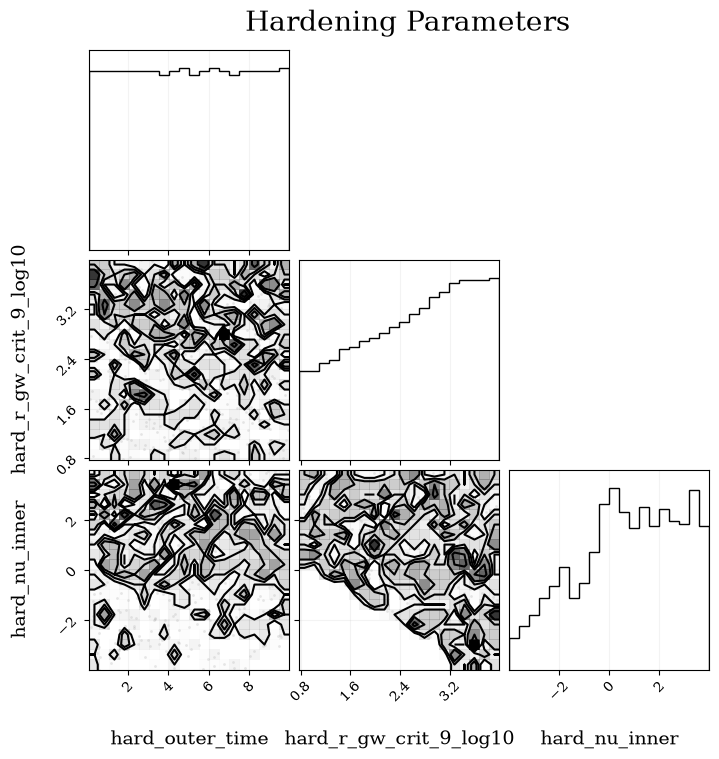

In [28]:
corner(samples_ng20_extended_arr[hardening_idx_e,:].T,labels=hardening_params_e,label_kwargs={'fontsize':14})
plt.suptitle('Hardening Parameters',x=0.55,y=1.0,fontsize=20)
plt.show()

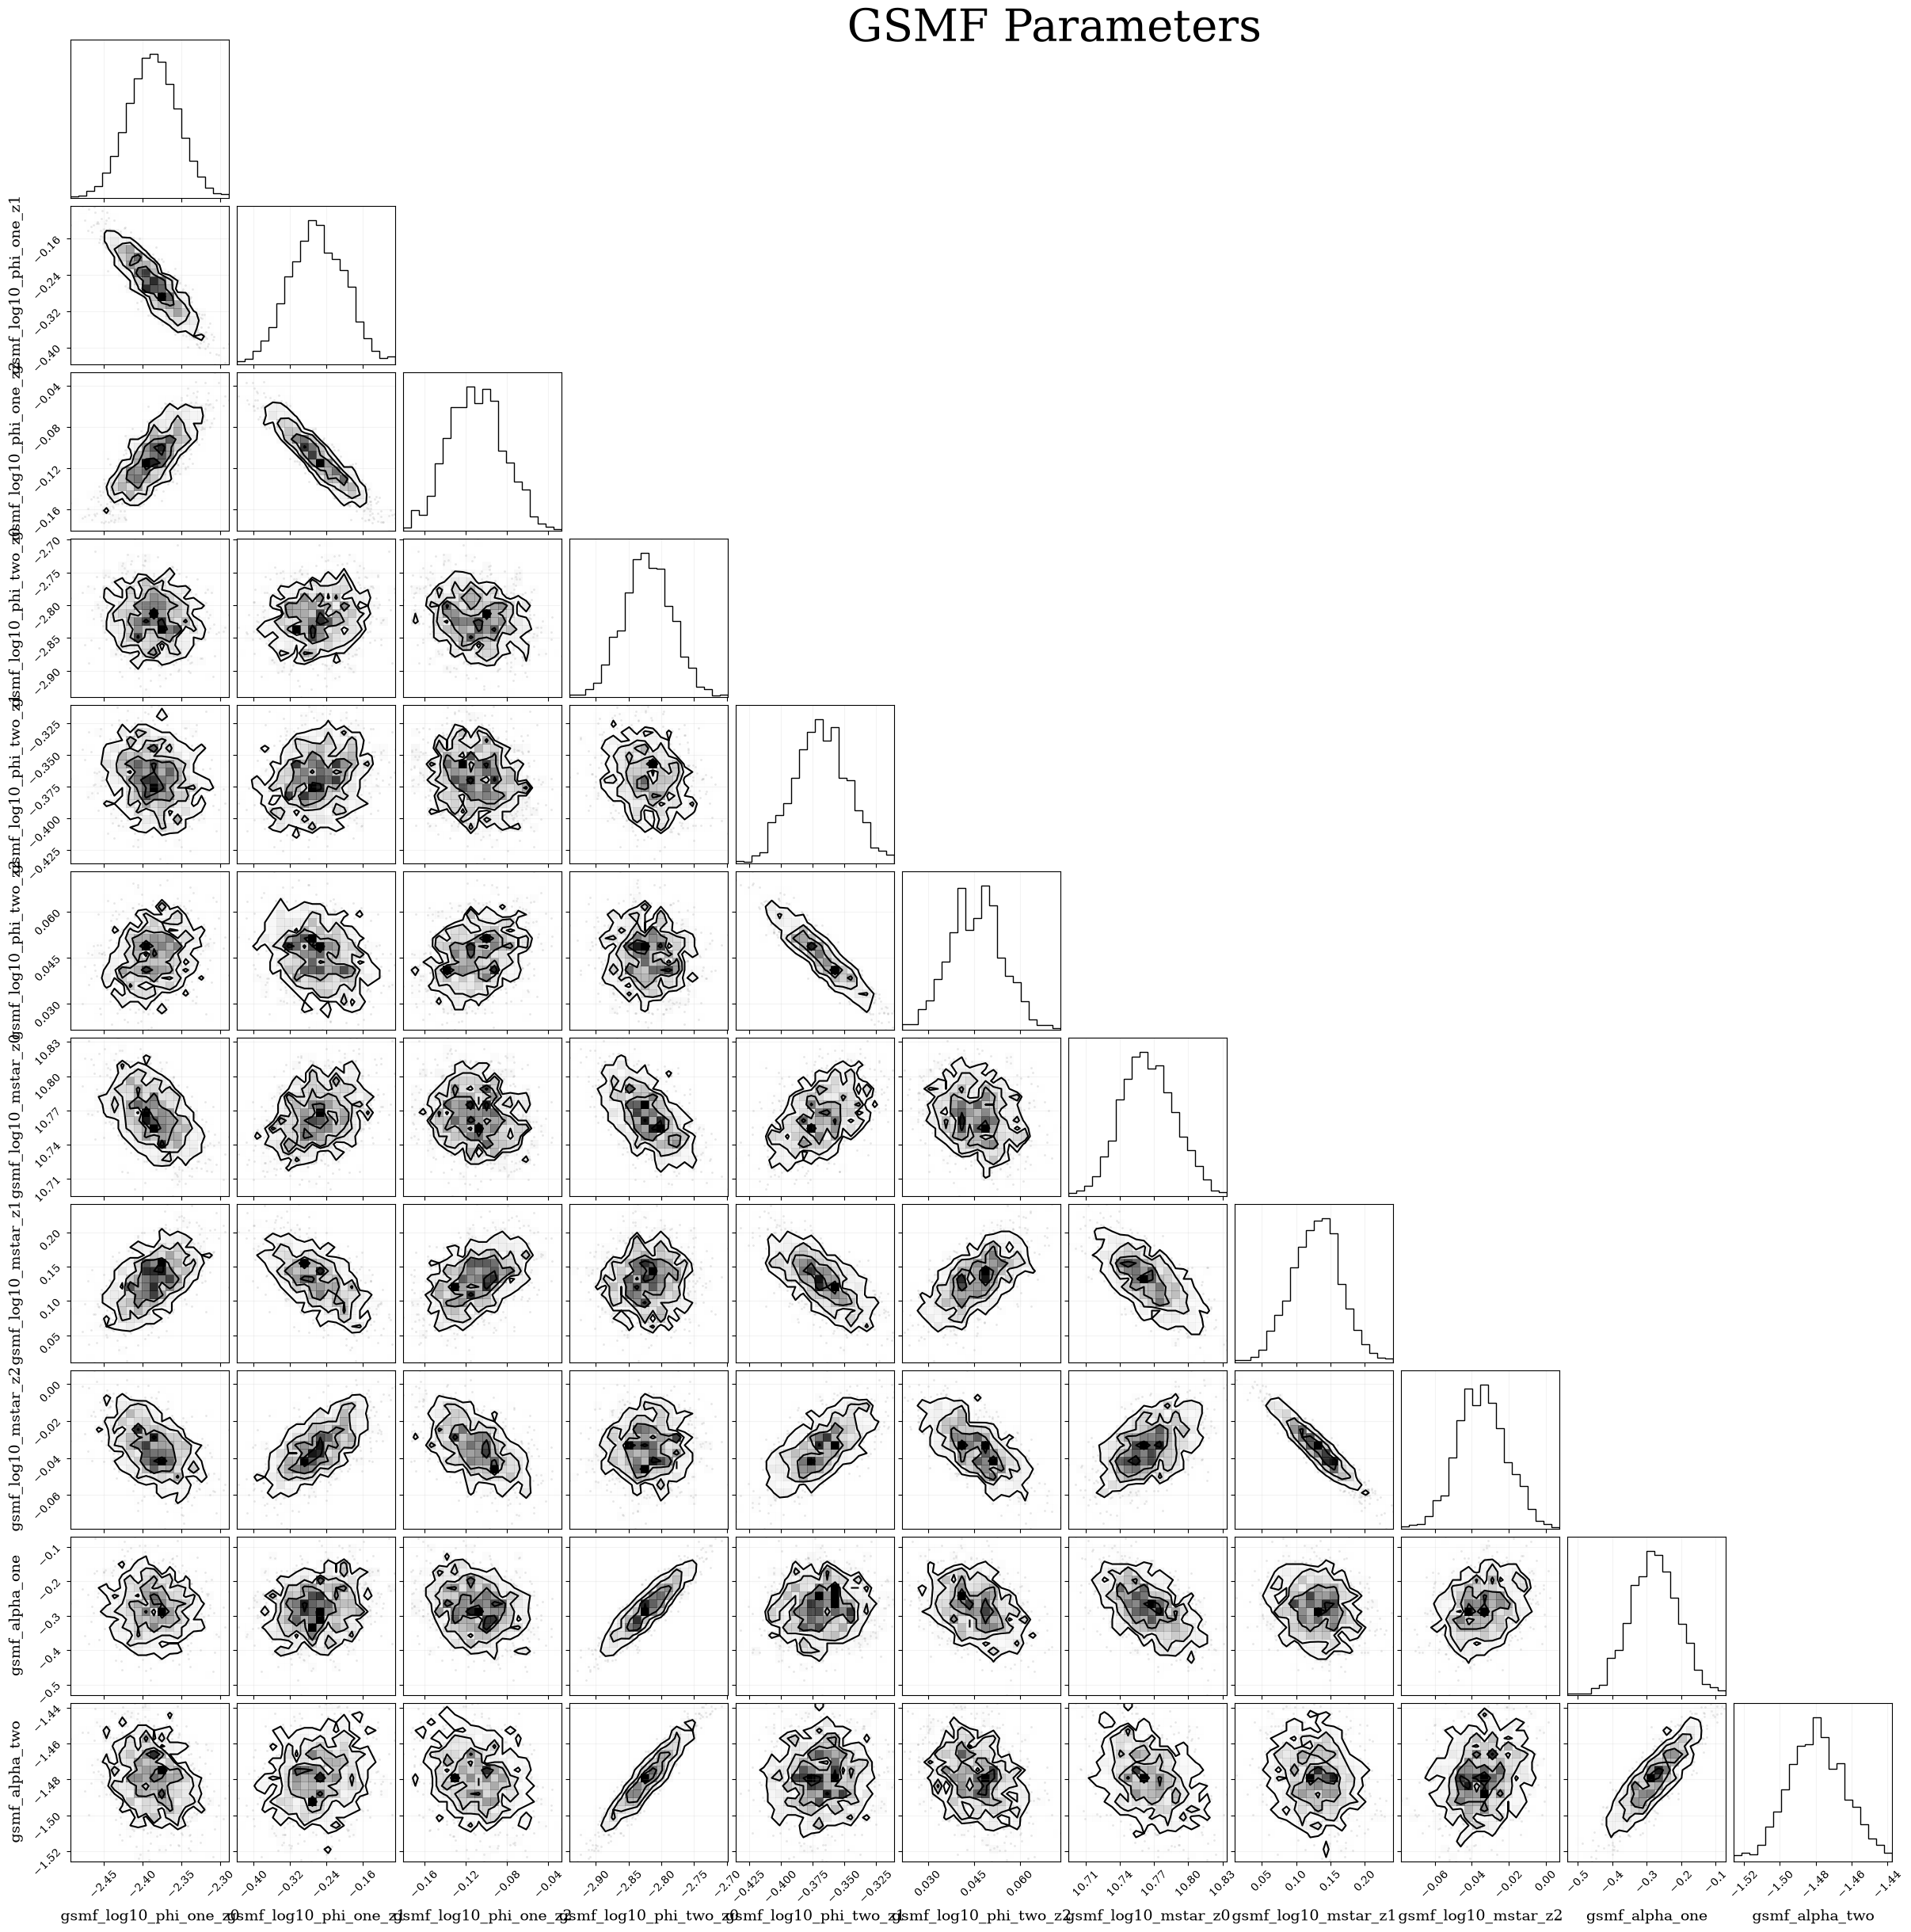

In [29]:
corner(samples_ng20_extended_arr[gsmf_idx_e,:].T,labels=gsmf_params_e,label_kwargs={'fontsize':14})
plt.suptitle('GSMF Parameters',x=0.55,y=1.0,fontsize=40)
plt.show()

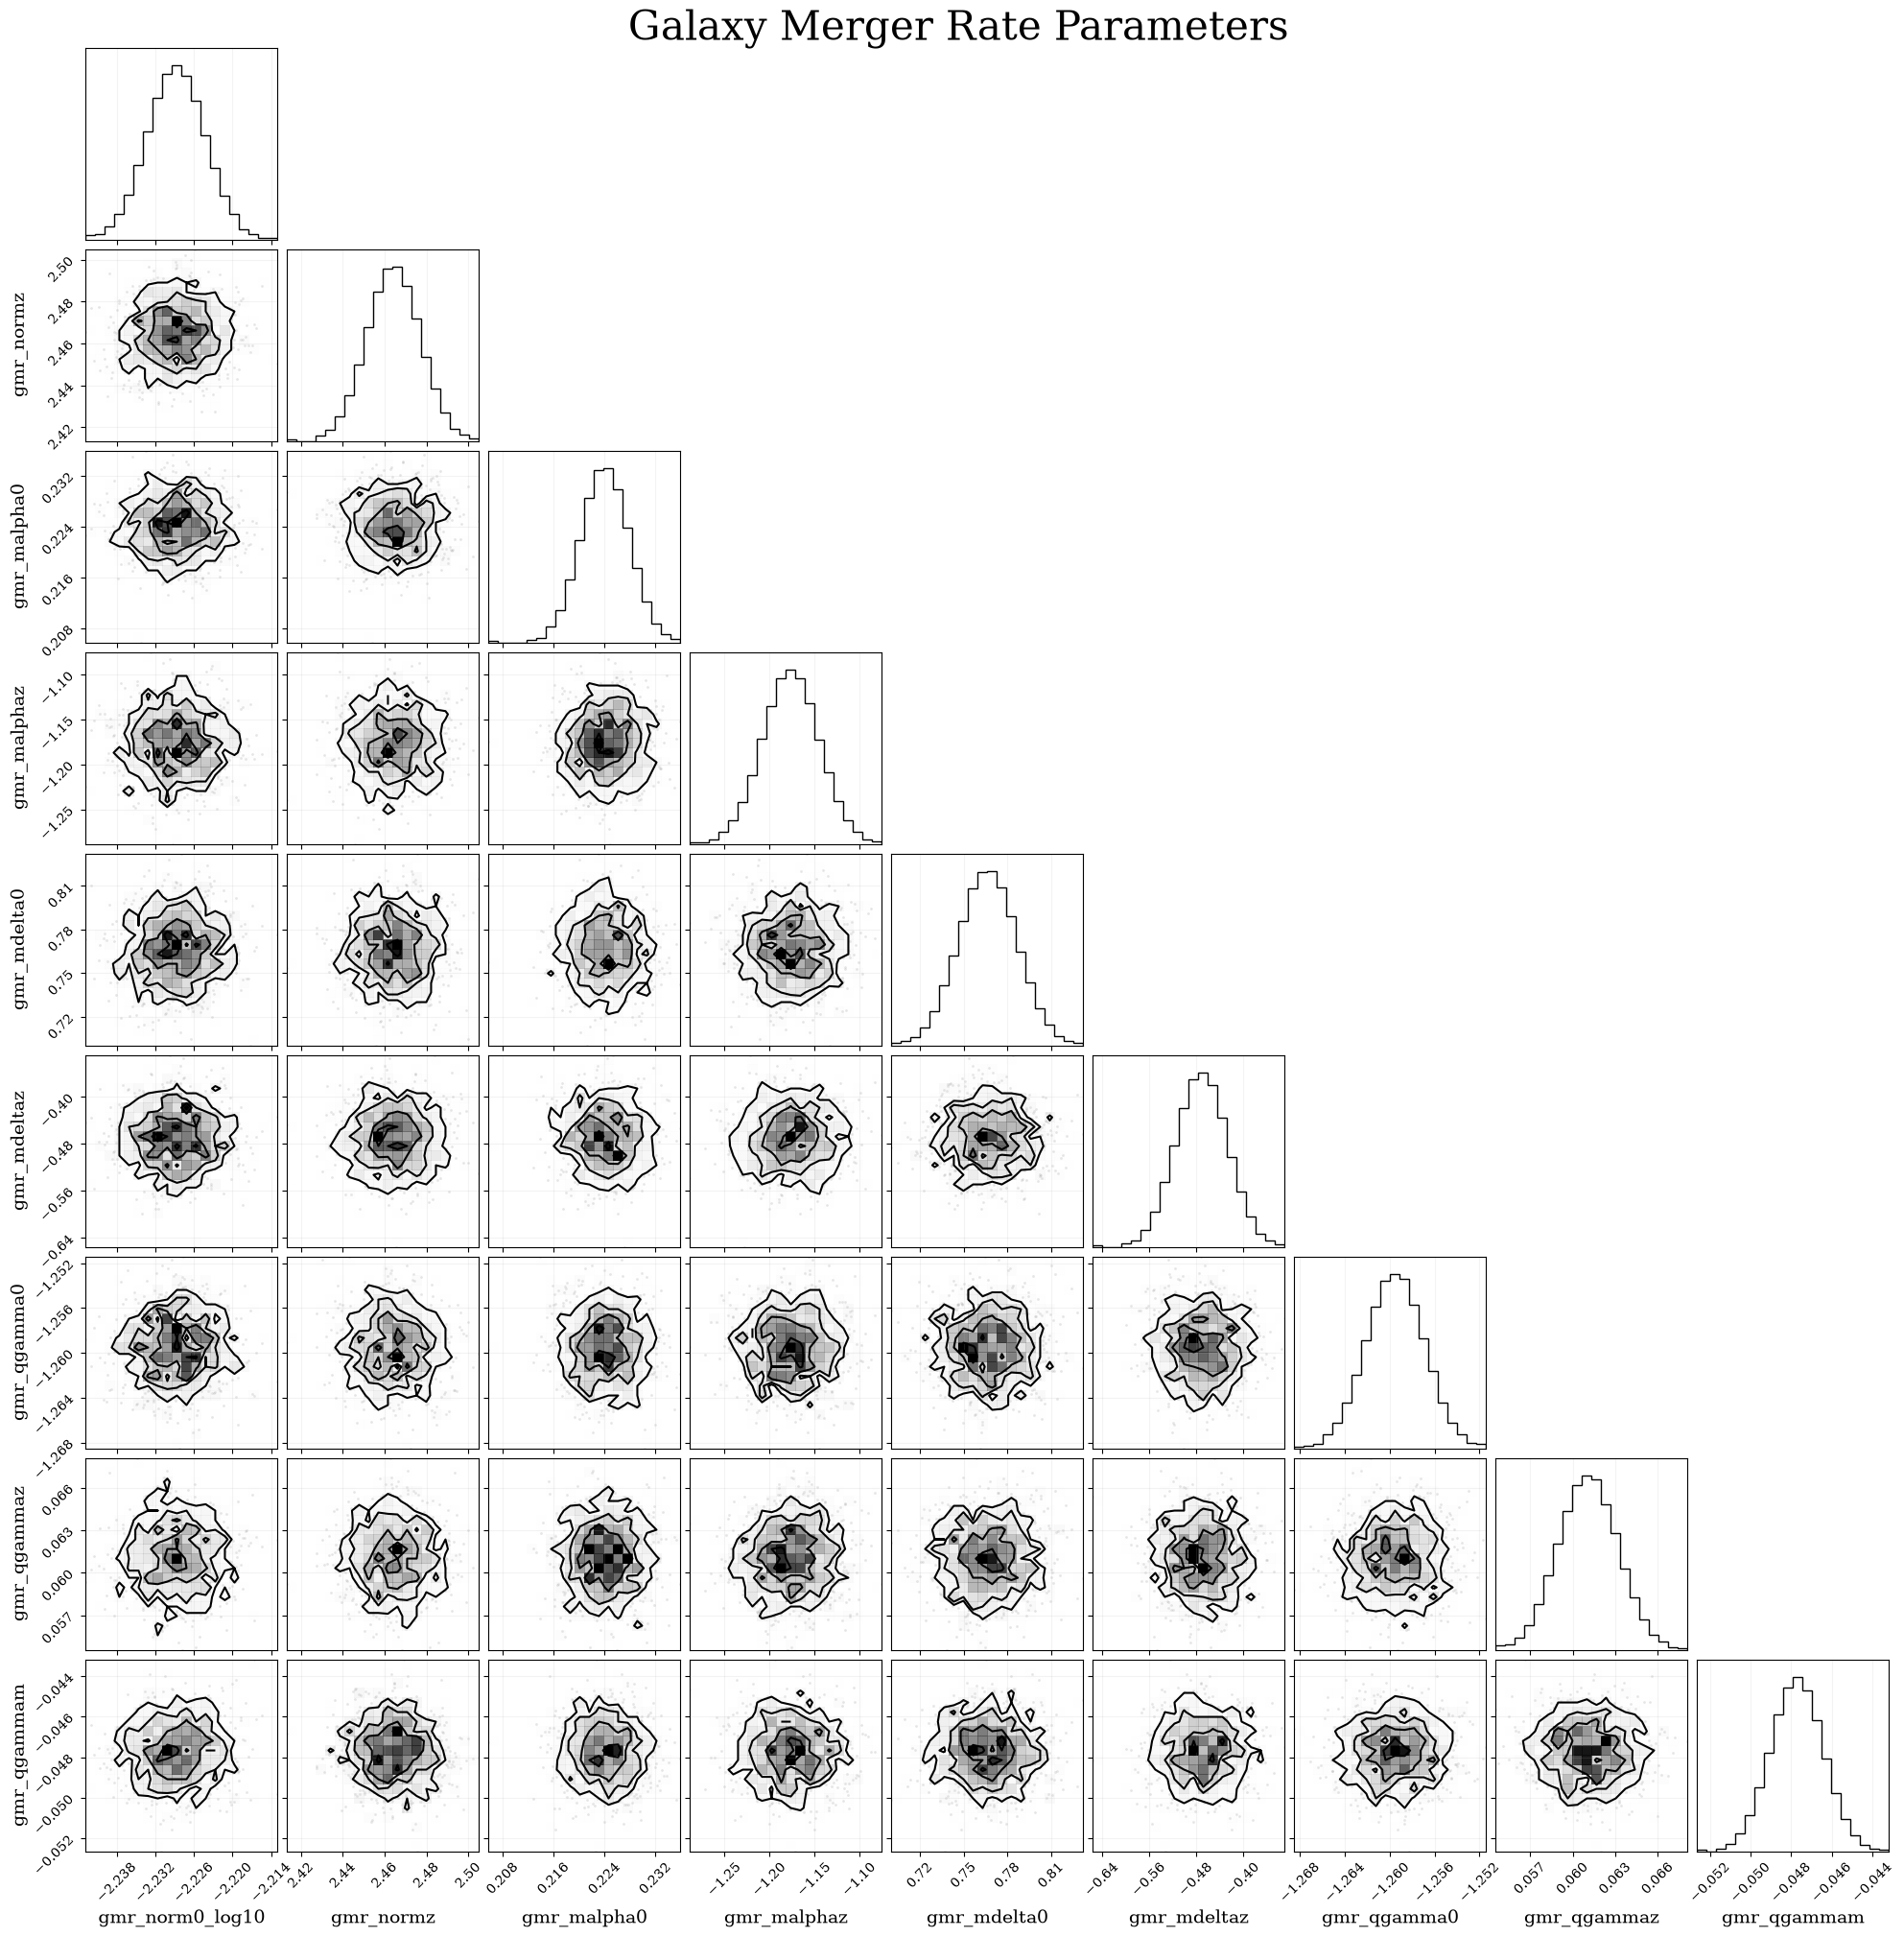

In [30]:
corner(samples_ng20_extended_arr[gmr_idx_e,:].T,labels=gmr_params_e,label_kwargs={'fontsize':14})
plt.suptitle('Galaxy Merger Rate Parameters',x=0.5,y=1.0,fontsize=30)
plt.show()

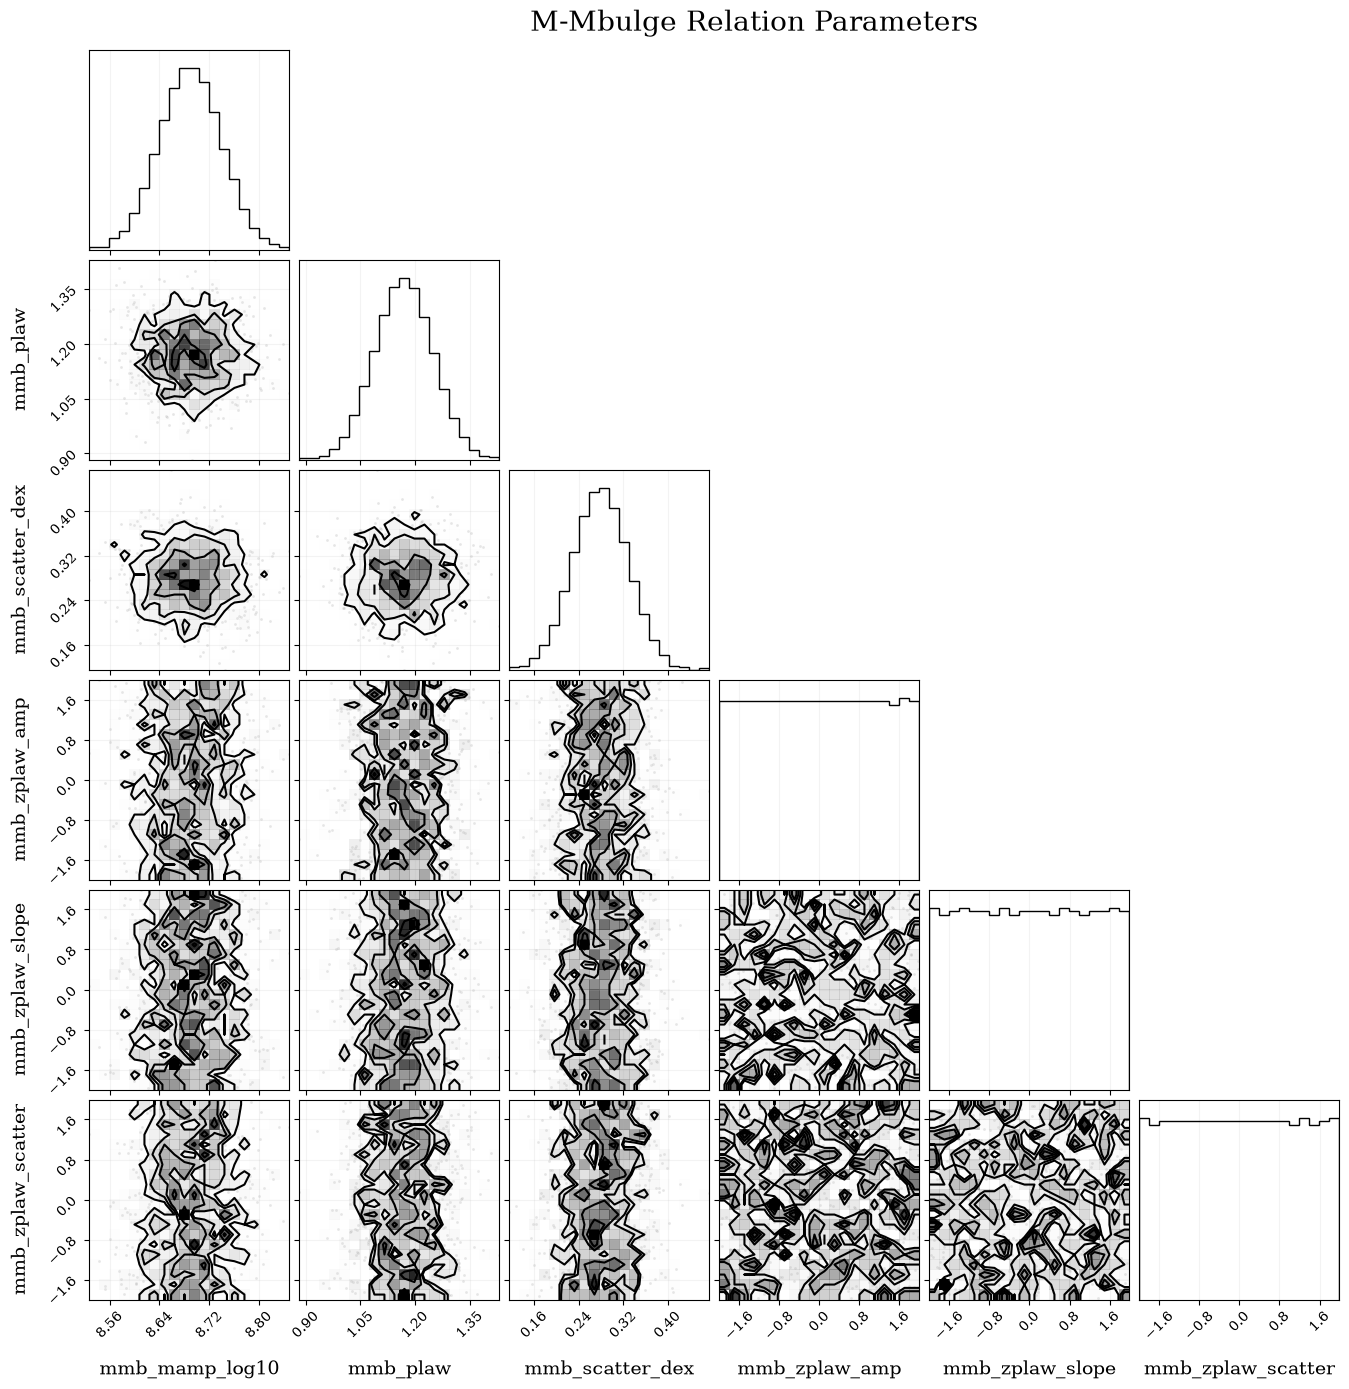

In [31]:
corner(samples_ng20_extended_arr[mmb_idx_e,:].T,labels=mmb_params_e,label_kwargs={'fontsize':14})
plt.suptitle('M-Mbulge Relation Parameters',x=0.55,y=1.0,fontsize=20)
plt.show()

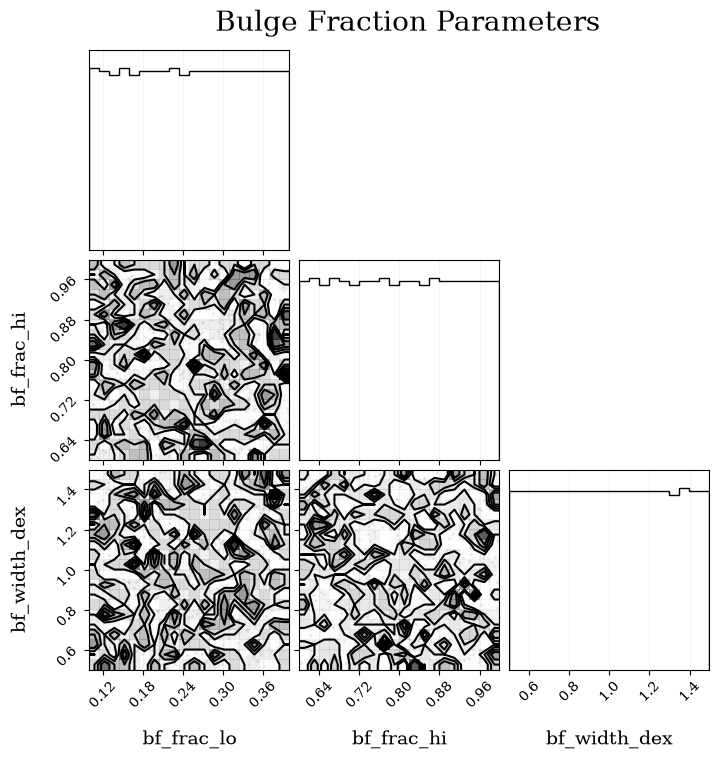

In [32]:
corner(samples_ng20_extended_arr[bf_idx_e,:].T,labels=bf_params_e,label_kwargs={'fontsize':14})
plt.suptitle('Bulge Fraction Parameters',x=0.55,y=1.0,fontsize=20)
plt.show()

## 4. Model Generation & Fast Spectrum Verification

Below we generate the Semi-Analytic Model (`Semi_Analytic_Model`) and BIO-Hardening (`FixedOuterTime_InnerPL_SAM`) objects from sample parameter dictionaries and compute GWB spectra on a compact grid to verify functionality for all parameter spaces.

18:23:15 INFO : No galaxy pair-fraction given, using galaxy merger-rate. [sam.py:__init__]
18:23:15 WARNING : SAM and nu_inner interpolator grid shape mismatch: 
mt_tup=(np.float64(1.9884098706980572e+37), np.float64(1.988409870698057e+45), 100), self.mtot_for_nuin_lims=(1.988409870698051e+37, 1.988409870698051e+45, 91), mr_tup=(np.float64(0.001), np.float64(1.0), 100), self.mrat_for_nuin_lims=(0.001, 1.0, 81) [lib_tools.py:model_for_params]
Constructed Default SAM: <holodeck.sams.sam.Semi_Analytic_Model object at 0x7462c1e1d460>
Constructed Default Hardening: <holodeck.hardening.FixedOuterTime_InnerPL_SAM object at 0x7462c1e1dd30> :: outer_time/Gyr=1.00e+00 num_steps=300 rchar_9/pc=1.00e-01 inner_model_type=0 0.00e+00 
18:23:15 INFO : No GMT was provided, cannot calculate Galaxy-Merger based stalling. [sam.py:static_binary_density]
18:23:15 INFO : Adding MMbulge scatter (2.8000e-01, 2.8000e-01, 2.8000e-01, 2.8000e-01, 2.8000e-01, 2.8000e-01, 2.8000e-01, 2.8000e-01, 2.8000e-01, 2.8000e

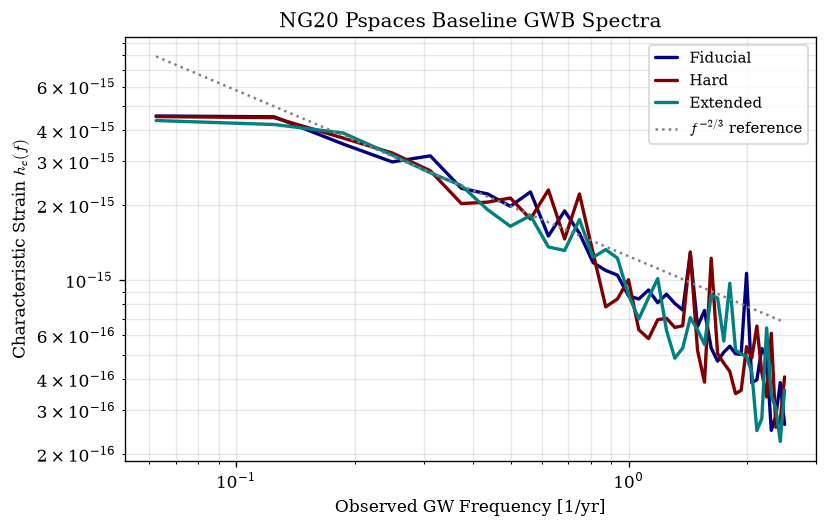

In [33]:
# Frequency bins for 16-yr baseline
freqs, f_edges = holo.utils.pta_freqs(dur=16.03*YR, num=40)

# Plot resulting default spectra
fig, ax = plt.subplots(figsize=(7, 4.5), dpi=120)
f_yr = freqs * YR

pnames = ['Fiducial','Hard','Extended']
cols = ['navy','maroon','teal']
for i, ps in enumerate([ps_ng20,ps_ng20_hard,ps_ng20_extended]):
    # Construct default model on full production grid shape=[100, 100, 100]
    sam_def, hard_def = ps.model_for_params(ps.DEFAULTS, sam_shape=[100, 100, 100])
    print("Constructed Default SAM:", sam_def)
    print("Constructed Default Hardening:", hard_def)
    
    # Calculate GWB for default parameters (2 realizations)
    h_ss_def, h_bg_def = sam_def.gwb(f_edges, hard=hard_def, realize=2)
    
    ax.plot(f_yr, h_bg_def[:, 0], label=pnames[i], color=cols[i], lw=2)
    # ax.plot(f_yr, h_bg_def[:, 1], label='Fiducial Default Realization 2', color='royalblue', lw=2, linestyle='--')

# Standard f^(-2/3) power law reference line
f_ref = f_yr[5]
h_ref = h_bg_def[5, 0]
ax.plot(f_yr, h_ref * (f_yr / f_ref)**(-2/3), color='gray', linestyle=':', label=r'$f^{-2/3}$ reference')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Observed GW Frequency [1/yr]')
ax.set_ylabel('Characteristic Strain $h_c(f)$')
ax.set_title('NG20 Pspaces Baseline GWB Spectra')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

## 4. Instructions for High-Resolution Library Generation

To produce full library datasets with high resolution (`sam_shape=[100, 100, 100]` or higher) for MCMC model evaluation:

```bash
# Generate a full library with 10,000 parameter points using gen_lib_sams.py
python scripts/gen_lib_sams.py --pspace PS_NG20_Fiducial --nsamples 10000 --shape 100 100 100 --outdir ./output/ng20_fiducial_lib/
```

Or via the SLURM orchestration script:
```bash
sbatch scripts/run_holodeck_lib_gen.sh PS_NG20_Fiducial 10000
```